# DSA 8301 — Kenya Housing Survey 2023/24
## Data Understanding · Cleaning · Feature Engineering
### Housing Financial Vulnerability Score (HFVS)

**Student:** Sephine Valerie Jerono | **No:** 222331  
**Supervisor:** Dr. John Olukuru  
**Institution:** Strathmore Institute of Mathematical Sciences (iLabAfrica)  
**Dataset:** KHS 2023/24 — KNBS · 21,347 households · 47 counties  

---

### Notebook Architecture

| Section | Purpose |
|---|---|
| §0 | Environment setup & paths |
| §1 | Data loading & structural audit |
| §2 | Missingness mapping & triage |
| §3 | Targeted cleaning (codes → semantics) |
| §4 | Feature engineering (three HFVS pillars) |
| §5 | Dimensionality reduction & final dataset assembly |
| §6 | Univariate & bivariate profiling |
| §7 | Export |

---

## §0 — Environment

In [253]:
# ── 0.1  Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [254]:
# ── 0.2  Core imports ────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import skew

warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 120)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '600', 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
sns.set_style('whitegrid')

TEAL  = '#00695C'; RED  = '#B71C1C'; AMBER = '#E65100'
BLUE  = '#1565C0'; GRAY = '#546E7A'; GREEN = '#2E7D32'

print('All imports loaded.')

All imports loaded.


In [255]:
# ── 0.3  Paths ───────────────────────────────────────────────────────────
DRIVE = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ    = DRIVE / 'data' / 'parquet'
FIGS  = DRIVE / 'outputs' / 'figures' / 'dsa8301'
TABS  = DRIVE / 'outputs' / 'tables'  / 'dsa8301'
for p in [FIGS, TABS]: p.mkdir(parents=True, exist_ok=True)

MASTER_PATH = PQ / 'master_frame.parquet'
print(f'Paths configured. master_frame.parquet exists: {MASTER_PATH.exists()}')

Paths configured. master_frame.parquet exists: True


In [256]:
# ── 0.4  Load master frame ───────────────────────────────────────────────
if not MASTER_PATH.exists():
    alt = PQ / 'master_frame_clean.parquet'
    if alt.exists():
        MASTER_PATH = alt
    else:
        raise FileNotFoundError(
            'master_frame.parquet not found. Re-run the exploration notebook '
            'and save: master_clean.to_parquet(PQ / "master_frame.parquet")'
        )

master = pd.read_parquet(MASTER_PATH)
print(f'Loaded master frame: {master.shape[0]:,} rows × {master.shape[1]} columns')

print(f'\nColumn groups present (prefix scan):')
for prefix in ['hh_', 'county_', 'a0', 'b0', 'c0', 'c1', 'd0', 'd1', 'e0',
               'g0', 'h0', 'i0', 'j0', 'k0', 'l0', 'lp_', 'dw_', 'mort_',
               'fin_', 'loan_', 'wsvc_', 'nema_']:
    cols = [c for c in master.columns if c.startswith(prefix)]
    if cols:
        print(f'  {prefix:<10} {len(cols):>3} columns')

Loaded master frame: 21,347 rows × 443 columns

Column groups present (prefix scan):
  hh_          1 columns
  a0           2 columns
  c0          32 columns
  c1          39 columns
  d0           1 columns
  d1          10 columns
  e0          33 columns
  g0          35 columns
  h0           9 columns
  i0           1 columns
  j0          18 columns
  k0          13 columns
  l0          16 columns
  lp_          7 columns
  dw_         11 columns
  mort_        4 columns
  fin_         3 columns
  loan_        3 columns
  wsvc_        5 columns
  nema_        3 columns


---
## §1 — Structural Audit

In [257]:
# ── 1.1  Shape, dtypes, duplicate keys ───────────────────────────────────
print('=== SHAPE ===')
print(f'Rows: {master.shape[0]:,}  |  Columns: {master.shape[1]}')

print('\n=== DTYPE DISTRIBUTION ===')
print(master.dtypes.value_counts())

print('\n=== DUPLICATE KEYS ===')
dup_key = master.duplicated('interview__key').sum()
print(f'Duplicate interview__key rows: {dup_key}')

print('\n=== COUNTY COVERAGE ===')
n_counties = master['a01'].nunique()
print(f'Counties represented: {n_counties} / 47')

print('\n=== URBAN / RURAL SPLIT ===')
# a07_1: 1=Urban, 2=Rural  (KNBS coding)
ur = master['a07_1'].value_counts().rename({1: 'Urban', 2: 'Rural'})
print(ur.to_string())
print(f'Urban share: {(master["a07_1"]==1).mean()*100:.1f}%')

=== SHAPE ===
Rows: 21,347  |  Columns: 443

=== DTYPE DISTRIBUTION ===
float64    363
object      40
int8        22
float32     15
Int64        1
int32        1
int16        1
Name: count, dtype: int64

=== DUPLICATE KEYS ===
Duplicate interview__key rows: 0

=== COUNTY COVERAGE ===
Counties represented: 47 / 47

=== URBAN / RURAL SPLIT ===
a07_1
Urban    11900
Rural     9447
Urban share: 55.7%


In [258]:
# ── 1.2  Zero-variance columns (no analytical value) ─────────────────────
zero_var_cols = []
for col in master.select_dtypes('number').columns:
    if master[col].nunique(dropna=True) <= 1:
        zero_var_cols.append(col)

print(f'Zero/single-value columns to drop: {zero_var_cols}')

Zero/single-value columns to drop: ['k26__96', 'l02__8', 'tag', 'internet']


In [259]:
# ── 1.3  String / free-text columns (mostly empty, no modelling value) ───
str_cols = [c for c in master.columns
            if master[c].dtype == object or str(master[c].dtype) == 'str']

print(f'String columns ({len(str_cols)}): {str_cols}')
print('\nAll are SurveySolutions "other-specify" free-text or UUID identifiers.')
print('They carry no structured signal. Will be dropped.')

String columns (40): ['interview__key', 'interview__id', 'countycode', 'c01_1other', 'c01_2other', 'c02_1other', 'c02_2other', 'c03_other', 'c04other', 'c07_1', 'c09_other', 'c10_1', 'c11_other', 'c12_other', 'c13_other', 'e02_1', 'e03_1', 'e04_1', 'j06_2_other', 'j12_2other', 'j16_1', 'j19_1', 'j22_1', 'k04_1', 'k11_1', 'k12_1', 'k16_1', 'k22_1', 'k26_other', 'k30_1', 'k32_1', 'k33_other', 'k36_1', 'k39_other', 'l01_1a', 'l01_2a', 'l16_a', 'l19a', 'l22_1a', 'l27_a']

All are SurveySolutions "other-specify" free-text or UUID identifiers.
They carry no structured signal. Will be dropped.


---
## §2 — Missingness Mapping & Triage

The KHS master frame has **three distinct classes of missingness**:

| Class | Description | Strategy |
|---|---|---|
| **Skip-logic MCAR** | Module only asked of a sub-group (renters, owners, land-holders) | Impute with a sentinel or drop; never drop rows |
| **Item non-response MAR** | Question was applicable but HH refused / didn't know | Impute with median/mode within stratum |
| **Structural absence** | County-level supply vars: county not surveyed | Forward-fill by county code |


In [260]:
# ── 2.1  Full missingness profile ────────────────────────────────────────
miss_n   = master.isnull().sum()
miss_pct = miss_n / len(master) * 100

miss_df = (pd.DataFrame({'missing_n': miss_n, 'missing_pct': miss_pct})
           .query('missing_n > 0')
           .sort_values('missing_pct', ascending=False))

# Tier the columns
miss_df['tier'] = pd.cut(
    miss_df['missing_pct'],
    bins=[-1, 5, 30, 70, 101],
    labels=['LOW (<5%)', 'MODERATE (5–30%)', 'HIGH (30–70%)', 'EXTREME (>70%)']
)

print('=== MISSINGNESS TIER SUMMARY ===')
print(miss_df['tier'].value_counts().to_string())
print()
print('=== EXTREME MISSING COLUMNS (>70%) ===')
extreme = miss_df[miss_df['missing_pct'] > 70]
print(extreme[['missing_pct','tier']].to_string())

=== MISSINGNESS TIER SUMMARY ===
tier
EXTREME (>70%)      133
LOW (<5%)           122
HIGH (30–70%)       100
MODERATE (5–30%)     18

=== EXTREME MISSING COLUMNS (>70%) ===
                    missing_pct            tier
k10                     99.9344  EXTREME (>70%)
k32                     99.7096  EXTREME (>70%)
k27                     99.3676  EXTREME (>70%)
k24_1                   99.3676  EXTREME (>70%)
l24                     99.3020  EXTREME (>70%)
l27__6                  99.2130  EXTREME (>70%)
l27__4                  99.2130  EXTREME (>70%)
l27__3                  99.2130  EXTREME (>70%)
l27__5                  99.2130  EXTREME (>70%)
l27__96                 99.2130  EXTREME (>70%)
l27__1                  99.2130  EXTREME (>70%)
l27__2                  99.2130  EXTREME (>70%)
k36                     99.1896  EXTREME (>70%)
l12                     98.9038  EXTREME (>70%)
l09                     98.4073  EXTREME (>70%)
l11                     98.3136  EXTREME (>70%)
l10       

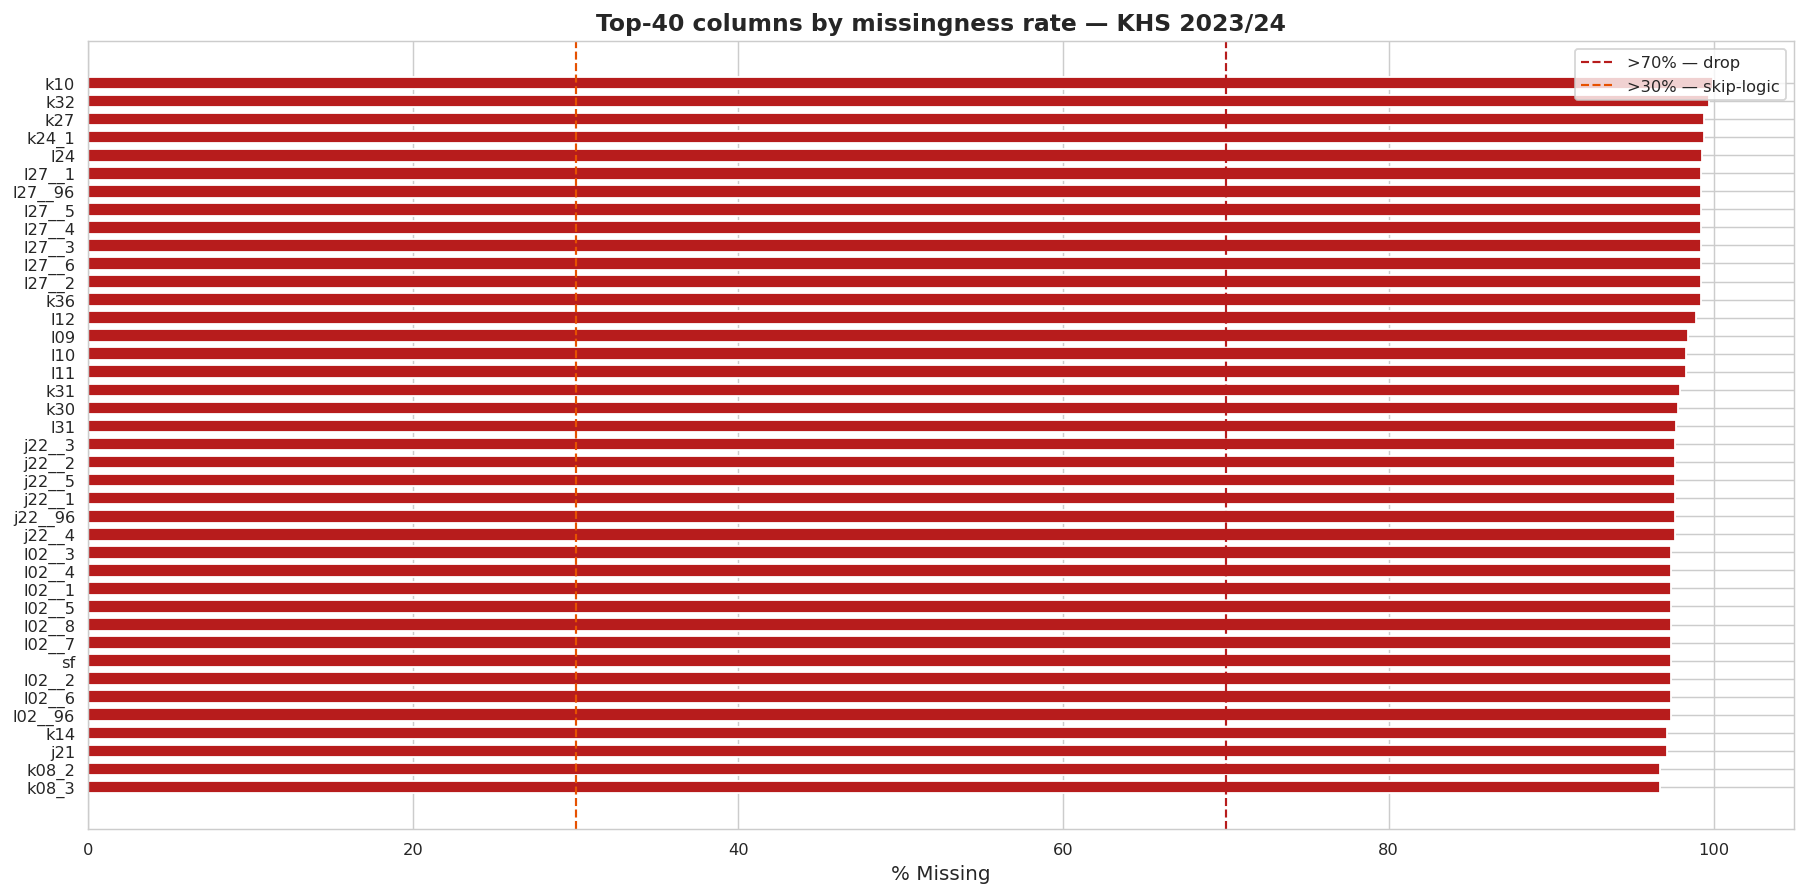

Figure saved.


In [261]:
# ── 2.2  Visualise missingness heatmap (top-40 affected columns) ─────────
top40_miss = miss_df.head(40).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))
miss_pct_plot = miss_pct[top40_miss].sort_values(ascending=True)
colors = [RED if v > 70 else AMBER if v > 30 else TEAL for v in miss_pct_plot]
ax.barh(miss_pct_plot.index, miss_pct_plot.values, color=colors, height=0.7)
ax.axvline(70, color=RED,   ls='--', lw=1.2, label='>70% — drop')
ax.axvline(30, color=AMBER, ls='--', lw=1.2, label='>30% — skip-logic')
ax.set_xlabel('% Missing')
ax.set_title('Top-40 columns by missingness rate — KHS 2023/24')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'missingness_barh.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## §3 — Targeted Cleaning

Cleaning proceeds in strict order:
1. Drop noise (zero-variance, all-empty free-text, columns >85% missing with no HFVS relevance)
2. Fix survey codes (sentinels −1/98/99/999 → NaN)
3. Fix known inversions (Urban/Rural, year columns)
4. Recode categorical variables to interpretable ordinals/dummies
5. Impute residual missingness by class


In [262]:
# ── 3.1  Working copy ────────────────────────────────────────────────────
df = master.copy()
print(f'Working copy: {df.shape}')

Working copy: (21347, 443)


In [263]:
# ── 3.2  Drop zero-variance & free-text columns ──────────────────────────

# Zero-variance
drop_zero_var = zero_var_cols

# Identifiers we must NEVER drop, even though they are dtype=object/string.
# interview__key is the unique household primary key used for every join,
# every export, and the §7.4 health check. interview__id is kept too as a
# secondary trace key (harmless to keep; drop later if truly unused).
ID_COLS_TO_PRESERVE = ['interview__key', 'interview__id']

# Free-text "other-specify" and UUID identifiers — EXCLUDING the ID columns
# above. (Previously this dropped ALL string columns indiscriminately.)
drop_freetext = [c for c in str_cols if c not in ID_COLS_TO_PRESERVE]

# Module K (renter-only) — most sub-items are 69%-99.9% missing and that
# signal is already captured in k05 (rent), k21 (arrears), k09 (lease type).
# RESTORED for D2 Tenure Insecurity (confirmed <70% missing, NOT noise):
#   k02 = written lease flag, k29 = rent dispute history,
#   k34 = neighbourhood demolition threat, k35 = eviction threat
k_deep = [c for c in df.columns
          if c.startswith('k') and c not in
          ['k05', 'k09', 'k21', 'k25', 'k13', 'k14', 'k07',
           'k02', 'k29', 'k34', 'k35']]   # <-- 4 columns restored here

# Module L sub-indicators mostly >97% missing (renovation detail, finance type)
l_deep = [c for c in df.columns
          if c.startswith('l') and c not in
          ['l07', 'l08', 'l13', 'l14', 'l15', 'l19', 'l21', 'l23', 'l24', 'l25', 'l26']]

# j16/j19/j22 relocation reason sub-items (>94% missing) — direction flags
# j06_2 move-reason sub-items (>30% missing duplicated by j06_1)
j_drop = ([c for c in df.columns if c.startswith('j16__')] +
          [c for c in df.columns if c.startswith('j19__')] +
          [c for c in df.columns if c.startswith('j22__')] +
          [c for c in df.columns if c.startswith('j06_2')])

# g06 aspirations (conditional only on those wanting improvement, 65-95% missing)
g06_drop = [c for c in df.columns if c.startswith('g06__')]

# l16 / l16b / l22_1 / l27 — renovation finance sub-items (>97% missing)
l_finance = ([c for c in df.columns if c.startswith('l16__')] +
             [c for c in df.columns if c.startswith('l16b__')] +
             [c for c in df.columns if c.startswith('l22_1__')] +
             [c for c in df.columns if c.startswith('l27__')] +
             [c for c in df.columns if c.startswith('l02__')])

# NEMA / supply-side county vars kept at county level — keep compact versions
# but drop granular sub-items with >80% missing
supply_drop = ['nema_eia_applications', 'nema_eia_approvals', 'nema_processing_days',
               'loan_avg_size', 'loan_outstanding', 'loan_n_providers',
               'fin_portfolio', 'fin_avg_tenure_months', 'fin_n_financiers',
               'mort_n_providers']

# Noise / survey admin columns
admin_drop = ['tag', 'serial', 'rnd', 'selectedage', 'a12']
# NOTE: 'interview__id' removed from this list — it now lives in
# ID_COLS_TO_PRESERVE above instead, so it survives as a trace key.

# c09 (source of water issue — sub-items) already captured by c01_1
c09_drop = [c for c in df.columns if c.startswith('c09__')]

# d18/d20 dwelling access granular items
d_drop = ([c for c in df.columns if c.startswith('d18__')] +
          [c for c in df.columns if c.startswith('d20__')])

# e02 waste type sub-items (captured by e01)
e02_drop = [c for c in df.columns if c.startswith('e02__')]

# c11_4 cooking sub-items (captured by c11)
c11_drop = [c for c in df.columns if c.startswith('c11_4__')]

all_drops = list(set(
    drop_zero_var + drop_freetext + k_deep + l_deep + j_drop +
    g06_drop + l_finance + supply_drop + admin_drop +
    c09_drop + d_drop + e02_drop + c11_drop
))

# Safety net: never drop a preserved ID column even if it sneaks into a
# prefix-based drop list above.
all_drops = [c for c in all_drops if c not in ID_COLS_TO_PRESERVE]

# Only drop what actually exists in df
all_drops = [c for c in all_drops if c in df.columns]
df.drop(columns=all_drops, inplace=True)

print(f'Dropped {len(all_drops)} columns  |  Remaining: {df.shape[1]}')
print(f'Preserved ID columns: {[c for c in ID_COLS_TO_PRESERVE if c in df.columns]}')
print(f'Restored D2 tenure-insecurity columns: '
      f'{[c for c in ["k02","k29","k34","k35"] if c in df.columns]}')


Dropped 248 columns  |  Remaining: 195
Preserved ID columns: ['interview__key', 'interview__id']
Restored D2 tenure-insecurity columns: ['k02', 'k29', 'k34', 'k35']


In [264]:
# ── 3.3  Replace SurveySolutions sentinel codes with NaN ─────────────────
# SurveySolutions uses -1=skipped, 98/998=don't know, 99/999=refused, 96=other
# We nullify -1 universally and the "don't know / refused" codes for numeric vars

SENTINEL_CODES = [-1, 98, 99, 998, 999]

num_cols = df.select_dtypes('number').columns.tolist()
replaced = 0
for col in num_cols:
    mask = df[col].isin(SENTINEL_CODES)
    replaced += mask.sum()
    df.loc[mask, col] = np.nan

print(f'Sentinel codes nullified: {replaced:,} cells across {len(num_cols)} numeric columns.')

Sentinel codes nullified: 10,419 cells across 193 numeric columns.


In [265]:
# 3.4c  j12_1 is survey year of occupancy — values < 100 are "duration" codes
# Values 1900–2024 are years; value==1 means <1 year; 99=DK
# We will handle this during feature engineering (yrs_in_dwelling)

if 'l28' in df.columns:
    df.loc[df['l28'] < 1900, 'l28'] = np.nan  # renovation year anomalies
    print(f'Renovation year (l28) after cleaning: n={df["l28"].notna().sum()}')
else:
    print('l28 (renovation year) not found in dataset — skipping.')

l28 (renovation year) not found in dataset — skipping.


In [266]:
print([c for c in df.columns if c.startswith('l')])

['l07', 'l08', 'l13', 'l14', 'l15', 'l19', 'l21', 'l23', 'l24', 'l25', 'l26']


In [267]:
# ── 3.4  Fix known inversions & anomalies ────────────────────────────────

# 3.4a  Urban/Rural binary: recode to 1=Urban, 0=Rural for clarity
# KNBS coding: a07_1==1 → Urban, a07_1==2 → Rural
df['is_urban'] = (df['a07_1'] == 1).astype('int8')
print('is_urban distribution:')
print(df['is_urban'].value_counts())

# 3.4b  Dwelling year built anomalies: l08<1920 or l08>2024 → NaN
# Note: l08=0 in SurveySolutions means not answered (tag rows with value=0)
bad_year_mask = (df['l08'] < 1920) | (df['l08'] > 2024)
print(f'\nAnomalous l08 (year built) values: {bad_year_mask.sum()}')
df.loc[bad_year_mask, 'l08'] = np.nan

# 3.4c  l28 (year last renovated) not present in this export.
# Using l21 (renovation done flag) as binary proxy instead.
if 'l21' in df.columns:
    print(f'Renovation flag (l21) distribution:\n{df["l21"].value_counts()}')
else:
    print('l21 (renovation flag) also absent — skipping renovation cleaning.')

# 3.4d  Floor area extremes: >p99 for residential is implausible
p99_area = df['dw_floor_area_m2'].quantile(0.99)
df.loc[df['dw_floor_area_m2'] > p99_area, 'dw_floor_area_m2'] = np.nan
print(f'\nFloor area p99 cap at {p99_area:.0f} m²')

# 3.4e  Rent extremes: k05 > p99 are likely data entry errors
p99_rent = df['k05'].quantile(0.99)
df.loc[df['k05'] > p99_rent, 'k05'] = np.nan
print(f'Rent p99 cap at {p99_rent:.0f} KES/month')

# 3.4f  Income sub-components: cap extreme outliers at p99 per component
g_cols = [c for c in df.columns if c.startswith('g01')]
for col in g_cols:
    p99 = df[col].quantile(0.99)
    df.loc[df[col] > p99, col] = np.nan
print(f'Income components (g01*) outliers capped at p99 — {len(g_cols)} cols.')

is_urban distribution:
is_urban
1    11900
0     9447
Name: count, dtype: int64

Anomalous l08 (year built) values: 0
Renovation flag (l21) distribution:
l21
0.0000    10892
1.0000     2269
Name: count, dtype: int64

Floor area p99 cap at 1200 m²
Rent p99 cap at 30000 KES/month
Income components (g01*) outliers capped at p99 — 11 cols.


In [268]:
# ── 3.5  County code — ensure integer and forward-fill ───────────────────
df['county_code'] = df['a01'].astype('Int64')
print('County codes missing:', df['county_code'].isna().sum())
print('Counties:', sorted(df['county_code'].dropna().unique().tolist()))

County codes missing: 0
Counties: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]


---
## §4 — Feature Engineering

The HFVS rests on **three pillars**. All engineered features map explicitly to one pillar:

| Pillar | Concept | Key raw inputs |
|---|---|---|
| **P1 — Financial Stress** | Rent burden, income fragility, expenditure gaps | g01*, g02_1, k05, c14_*, j09–j11 |
| **P2 — Physical Quality** | Structure, services, overcrowding, environment | dw_*, c01_1, c04, c10, c11, h01–h11, e05–e07 |
| **P3 — Tenure Security** | Ownership, title, dispute, mobility | j04_1, lp_*, k21, j13, d01 |


In [269]:
# ── 4.1  PILLAR 1: Financial Stress ──────────────────────────────────────

# --- 4.1a  Total household expenditure proxy ---
# g01a–k = food, clothing, education, health, transport, comms,
#           recreation, housing costs, energy, other, remittances
g_expenditure_cols = [f'g01{x}' for x in 'abcdefghijk']
g_available = [c for c in g_expenditure_cols if c in df.columns]
df['total_expenditure'] = df[g_available].sum(axis=1, min_count=6)  # need ≥6 components
print(f'total_expenditure: n={df["total_expenditure"].notna().sum():,}  mean={df["total_expenditure"].mean():.0f} KES')

# --- 4.1b  Housing cost burden ---
# For renters: housing_cost = k05 (monthly rent)
# For owners:  housing_cost = l15 (monthly mortgage) if available, else g01h (reported housing costs)
# Unified: use g01h as it covers all tenure types
df['housing_cost_kes'] = df['g01h'].fillna(df['k05'].fillna(df['l15']))
print(f'housing_cost_kes: n={df["housing_cost_kes"].notna().sum():,}  mean={df["housing_cost_kes"].mean():.0f} KES')

# --- 4.1c  Housing cost burden ratio ---
# WHO/UN-Habitat threshold: >30% of income = burdened
df['housing_burden_ratio'] = np.where(
    df['total_expenditure'] > 0,
    df['housing_cost_kes'] / df['total_expenditure'],
    np.nan
)
# Cap at 1.0 (some HHs spend >100% — measurement error or borrowing)
df['housing_burden_ratio'] = df['housing_burden_ratio'].clip(0, 1)

df['is_cost_burdened'] = (df['housing_burden_ratio'] > 0.30).astype('float')
print(f'\nhousing_burden_ratio: mean={df["housing_burden_ratio"].mean():.3f}')
print(f'is_cost_burdened (>30%): {df["is_cost_burdened"].mean()*100:.1f}% of households')

# --- 4.1d  Utility expenditure share ---
# c14_1=water, c14_2=electricity, c14_3=other energy
df['utility_expenditure'] = df[['c14_1','c14_2','c14_3']].sum(axis=1, min_count=1)
df['utility_burden_ratio'] = np.where(
    df['total_expenditure'] > 0,
    df['utility_expenditure'] / df['total_expenditure'],
    np.nan
).clip(0, 1)
print(f'\nutility_burden_ratio: mean={df["utility_burden_ratio"].mean():.3f}')

# --- 4.1e  Self-reported financial stress flags ---
# j09: could not pay rent/mortgage last 12 months
# j10: skipped meals due to inability to pay housing costs
# j11: took on debt to meet housing costs
stress_cols = ['j09', 'j10', 'j11']
df['financial_stress_count'] = df[stress_cols].sum(axis=1, min_count=1)
df['any_financial_stress']   = (df['financial_stress_count'] > 0).astype('float')
print(f'\nany_financial_stress: {df["any_financial_stress"].mean()*100:.1f}% of households')

# --- 4.1f  Rent arrears (renter-only) ---
# k21: 1=no arrears, 2=1-3 months, 3=>3 months
# Recode: 0=no arrears, 1=in arrears
df['in_rent_arrears'] = np.where(
    df['k21'].notna(), (df['k21'] > 1).astype('float'), np.nan
)
print(f'in_rent_arrears: {df["in_rent_arrears"].mean()*100:.1f}% of renters')

# --- 4.1g  Income proxies from asset ownership ---
# c13__1=radio, c13__2=phone, c13__3=TV, c13__4=computer,
# c13__5=motorcycle, c13__6=car, c13__7=fridge
asset_cols = [f'c13__{i}' for i in [1,2,3,4,5,6,7] if f'c13__{i}' in df.columns]
asset_weights = {'c13__1':1, 'c13__2':1, 'c13__3':2, 'c13__4':3,
                 'c13__5':2, 'c13__6':4, 'c13__7':2}
df['asset_score'] = sum(
    df[c].fillna(0) * asset_weights.get(c, 1)
    for c in asset_cols
)
print(f'\nasset_score: mean={df["asset_score"].mean():.2f}, max={df["asset_score"].max()}')

print('\n✓ Pillar 1 (Financial Stress) features created.')

total_expenditure: n=21,298  mean=26437 KES
housing_cost_kes: n=21,339  mean=5212 KES

housing_burden_ratio: mean=0.143
is_cost_burdened (>30%): 11.7% of households

utility_burden_ratio: mean=0.617

any_financial_stress: 51.8% of households
in_rent_arrears: 44.0% of renters

asset_score: mean=0.56, max=15.0

✓ Pillar 1 (Financial Stress) features created.


In [270]:
# ── 4.2  DIMENSION 4: Dwelling Quality ───────────────────────────────────

# --- 4.2a  Wall material quality score (1=high, 0=low) ---
wall_durable = {1, 2, 3, 6}
wall_poor = {5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}
df['wall_durable'] = df['dw_wall_material'].map(
    lambda x: 1 if x in wall_durable else (0 if x in wall_poor else np.nan)
)

# --- 4.2b  Roof material quality ---
roof_durable = {1, 2, 3}
roof_poor = {5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15}
df['roof_durable'] = df['dw_roof_material'].map(
    lambda x: 1 if x in roof_durable else (0 if x in roof_poor else np.nan)
)

# --- 4.2c  Floor material quality ---
floor_durable = {1, 2, 4}
floor_poor = {3, 5, 6, 7, 8, 9}
df['floor_durable'] = df['dw_floor_material'].map(
    lambda x: 1 if x in floor_durable else (0 if x in floor_poor else np.nan)
)

# --- 4.2d  Composite structure quality score (0-3) ---
# NOTE: this composite + its 3 components are KEPT side by side deliberately.
# The dimensionality-control step at §5.3b will detect the redundancy
# (structure_quality is literally their sum) and prune automatically rather
# than us hand-picking which one survives.
structure_cols = ['wall_durable', 'roof_durable', 'floor_durable']
df['structure_quality'] = df[structure_cols].sum(axis=1, min_count=2)
print(f'structure_quality (0-3): mean={df["structure_quality"].mean():.2f}')

# --- 4.2e  Overcrowding ---
df['persons_per_room'] = df['hh_size'] / df['dw_n_rooms'].replace(0, np.nan)
df['is_overcrowded'] = (df['persons_per_room'] > 2).astype('float')
print(f'is_overcrowded (>2 p/room): {df["is_overcrowded"].mean()*100:.1f}% of households')

# --- 4.2f  Perceived housing quality (h01-h11, 1=Good, 3=Poor) ---
h_cols = [f'h{i:02d}' for i in range(1, 12)]
h_available = [c for c in h_cols if c in df.columns]
h_inverted = df[h_available].apply(lambda x: 4 - x)
df['perception_quality_score'] = h_inverted.mean(axis=1)
print(f'perception_quality_score: mean={df["perception_quality_score"].mean():.2f} (1=Poor, 3=Good)')

# --- 4.2g  Dwelling age ---
df['dwelling_age_yrs'] = (2024 - df['l08']).clip(0, 100)
df['dwelling_age_yrs'] = df['dwelling_age_yrs'].where(df['l08'].notna(), np.nan)
print(f'dwelling_age_yrs: mean={df["dwelling_age_yrs"].mean():.1f} yrs')

# --- 4.2h  Housing problems composite (structural/quality items only —
#           overcrowding/water/sanitation sub-items moved out since those
#           already have dedicated D5 features and would double-count) ---
g05_quality = [f'g05__{i}' for i in [1, 4, 5, 6, 7] if f'g05__{i}' in df.columns]
df['n_housing_problems'] = df[g05_quality].sum(axis=1, min_count=2)
print(f'n_housing_problems: mean={df["n_housing_problems"].mean():.2f}')

print('\n✓ Dimension D4 (Dwelling Quality) features created.')


# ── 4.2i  DIMENSION 5: Utility Deprivation ───────────────────────────────

# --- Safe water access ---
safe_water = {1, 2, 3, 4, 5, 6}   # JMP "improved" sources
df['safe_water'] = df['c01_1'].map(
    lambda x: 1 if x in safe_water else (0 if pd.notna(x) else np.nan)
)
print(f'safe_water: {df["safe_water"].mean()*100:.1f}% have improved water')

# --- Improved sanitation ---
improved_san = {1, 2, 3, 4, 5}  # JMP "improved" (excluding shared)
df['improved_sanitation'] = df['c04'].map(
    lambda x: 1 if x in improved_san else (0 if pd.notna(x) else np.nan)
)
print(f'improved_sanitation: {df["improved_sanitation"].mean()*100:.1f}% have improved sanitation')

# --- Shared sanitation facility (NEW — c05 confirmed present in schema,
#     referenced in README's D5 spec "(c04, c05)" but never engineered) ---
# ASSUMPTION TO VERIFY: c05 is treated as "1 = facility is shared with other
# households" (which downgrades JMP status from 'basic' to 'limited').
# Check the printed value_counts below; if c05 turns out to be coded the
# other way round, flip the condition.
if 'c05' in df.columns:
    print(f'\nc05 raw value_counts (verify coding before trusting the recode):')
    print(df['c05'].value_counts(dropna=False))
    df['shared_sanitation'] = (df['c05'] == 1).astype('float')
    print(f'shared_sanitation: {df["shared_sanitation"].mean()*100:.1f}% (assumed 1=shared)')
else:
    df['shared_sanitation'] = np.nan
    print('c05 not found in df at this point — shared_sanitation set to NaN.')

# --- Clean energy for cooking ---
clean_cooking = {1, 2, 4, 11, 12}
df['clean_cooking'] = df['c11'].map(
    lambda x: 1 if x in clean_cooking else (0 if pd.notna(x) else np.nan)
)
print(f'clean_cooking: {df["clean_cooking"].mean()*100:.1f}% use clean fuel')

# --- Electricity access ---
electricity = {1, 2, 3, 4}
df['has_electricity'] = df['c10'].map(
    lambda x: 1 if x in electricity else (0 if pd.notna(x) else np.nan)
)
print(f'has_electricity: {df["has_electricity"].mean()*100:.1f}% have electricity')

print('\n✓ Dimension D5 (Utility Deprivation) features created.')

structure_quality (0-3): mean=2.67
is_overcrowded (>2 p/room): 56.5% of households
perception_quality_score: mean=1.80 (1=Poor, 3=Good)
dwelling_age_yrs: mean=4.0 yrs
n_housing_problems: mean=1.52

✓ Dimension D4 (Dwelling Quality) features created.
safe_water: 60.0% have improved water
improved_sanitation: 20.1% have improved sanitation

c05 raw value_counts (verify coding before trusting the recode):
c05
0.0000    11625
1.0000     7910
NaN        1812
Name: count, dtype: int64
shared_sanitation: 37.1% (assumed 1=shared)
clean_cooking: 18.3% use clean fuel
has_electricity: 63.8% have electricity

✓ Dimension D5 (Utility Deprivation) features created.


In [271]:
# ── 4.2j  DIMENSION 3: Physical Hazard ───────────────────────────────────

# --- Flood / landslide risk (unchanged from original P2 logic) ---
df['flood_risk'] = (df['e05'] == 1).astype('float')
df['landslide_risk'] = (df['e06'] > 0).astype('float')

# --- Other environmental hazard flag (e07), plus e08 if present ---
other_hazard_cols = [c for c in ['e07', 'e08'] if c in df.columns]
if other_hazard_cols:
    df['other_hazard_flag'] = (df[other_hazard_cols].fillna(0) > 0).any(axis=1).astype('float')
else:
    df['other_hazard_flag'] = np.nan

# --- Proximity-hazard count (e09__1 ... e09__13: swamp/dumpsite/factory/
#     busy road/river and other sub-categories — multi-select dummies,
#     same encoding pattern as c13__*/g05__*/d18__* used elsewhere in this
#     notebook, so summing them directly is consistent with the rest of
#     your pipeline) ---
e09_cols = [c for c in df.columns if c.startswith('e09__')]
print(f'e09 proximity-hazard sub-items found: {len(e09_cols)} -> {e09_cols}')
if e09_cols:
    df['hazard_proximity_count'] = df[e09_cols].sum(axis=1, min_count=1)
else:
    df['hazard_proximity_count'] = np.nan
print(f'hazard_proximity_count: mean={df["hazard_proximity_count"].mean():.2f}')

# --- Composite "any hazard" flag, now folding in proximity hazards too ---
df['env_hazard_any'] = (
    (df['flood_risk'] == 1) |
    (df['landslide_risk'] == 1) |
    (df['other_hazard_flag'] == 1) |
    (df['hazard_proximity_count'].fillna(0) > 0)
).astype('float')

print(f'flood_risk: {df["flood_risk"].mean()*100:.1f}%')
print(f'env_hazard_any: {df["env_hazard_any"].mean()*100:.1f}%')
print('\n✓ Dimension D3 (Physical Hazard) features created.')


e09 proximity-hazard sub-items found: 13 -> ['e09__1', 'e09__2', 'e09__3', 'e09__4', 'e09__5', 'e09__6', 'e09__7', 'e09__8', 'e09__9', 'e09__10', 'e09__11', 'e09__12', 'e09__13']
hazard_proximity_count: mean=1.39
flood_risk: 44.2%
env_hazard_any: 100.0%

✓ Dimension D3 (Physical Hazard) features created.


In [272]:
df.columns

Index(['interview__key', 'interview__id', 'a01', 'a07_1', 'c01_1', 'c01_2',
       'c01_3', 'c01_4', 'c01_5', 'c02_1',
       ...
       'safe_water', 'improved_sanitation', 'shared_sanitation',
       'clean_cooking', 'has_electricity', 'flood_risk', 'landslide_risk',
       'other_hazard_flag', 'hazard_proximity_count', 'env_hazard_any'],
      dtype='object', length=226)

In [273]:
# Run this diagnostic in a new cell BEFORE 4.3d to find the real column names
land_cols = [c for c in df.columns if any(x in c.lower() for x in ['title', 'deed', 'dispute', 'register', 'parcel', 'lp_', 'land'])]
print(land_cols)
print(df[land_cols].head())

['landslide_risk']
   landslide_risk
0          0.0000
1          0.0000
2          0.0000
3          0.0000
4          0.0000


In [274]:
# ── 4.3  DIMENSION 2: Tenure Insecurity ──────────────────────────────────

# --- 4.3a  Tenure type ordinal (unchanged) ---
tenure_security_map = {
    2: 3, 5: 2, 6: 2, 1: 1, 4: 1, 3: 0, 7: 0,
}
df['tenure_security_score'] = df['d01'].map(tenure_security_map)
print('tenure_security_score (0=insecure, 3=secure):')
print(df['tenure_security_score'].value_counts().sort_index())

# --- 4.3b  Renter flag ---
df['is_renter'] = (df['j04_1'] == 1).astype('int8')
print(f'\nis_renter: {df["is_renter"].mean()*100:.1f}%')

# --- 4.3c  Land ownership (NEW — i00 confirmed present in schema) ---
# Per the README's own documented fix: i00 is coded 0=No/1=Yes (binary
# CAPI code), so i00==0 means "no land ownership".
df['no_land_ownership'] = (df['i00'] == 0).astype('float')
print(f'no_land_ownership: {df["no_land_ownership"].mean()*100:.1f}%')

# --- 4.3d  Land parcel security (NEW — lp_* aggregates, already merged
#     into the household spine at the master-frame stage; these are the
#     real columns your old FEATURE_MAP tried to reach under nonexistent
#     names 'has_title_deed' / 'land_dispute') ---
if 'lp_has_title' in df.columns:
    df['has_title_deed'] = df['lp_has_title']
    print(f'has_title_deed: {df["has_title_deed"].mean()*100:.1f}%')
else:
    df['has_title_deed'] = np.nan

if 'lp_any_dispute' in df.columns:
    df['land_dispute'] = df['lp_any_dispute']
    print(f'land_dispute: {df["land_dispute"].mean()*100:.1f}%')
else:
    df['land_dispute'] = np.nan

if 'lp_any_registered' in df.columns:
    df['land_registered'] = df['lp_any_registered']
    print(f'land_registered: {df["land_registered"].mean()*100:.1f}%')
else:
    df['land_registered'] = np.nan

# --- 4.3e  Lease / dispute / threat flags restored from module K ---
# ASSUMPTION TO VERIFY: these are treated as standard KNBS Yes/No fields
# coded 1=Yes/2=No (the dominant convention elsewhere in this dataset,
# e.g. a07_1, hhh_sex), so "condition present" = value==1 and
# "No"/lease-exists = value==2. Check the printed value_counts first —
# if these turn out to follow k21's 3-level pattern instead, change the
# condition to `> 1` to match.
for raw_col, new_col, vulnerable_value in [
    ('k02', 'no_written_lease', 2),
    ('k29', 'rent_dispute_history', 1),
    ('k34', 'demolition_threat', 1),
    ('k35', 'eviction_threat', 1),
]:
    if raw_col in df.columns:
        print(f'\n{raw_col} raw value_counts (verify coding before trusting the recode):')
        print(df[raw_col].value_counts(dropna=False))
        df[new_col] = (df[raw_col] == vulnerable_value).astype('float')
        print(f'{new_col}: {df[new_col].mean()*100:.1f}% (assumed {raw_col}=={vulnerable_value} = vulnerable)')
    else:
        df[new_col] = np.nan
        print(f'{raw_col} not found in df — {new_col} set to NaN.')

# --- 4.3f  Tenure dissatisfaction (unchanged) ---
df['tenure_satisfied'] = df['j13']

# --- 4.3g  Years in dwelling (unchanged) ---
def decode_years_in_dwelling(val):
    if pd.isna(val):
        return np.nan
    if val >= 1900:
        return max(0, 2024 - val)
    elif val <= 50:
        return val
    else:
        return np.nan

df['yrs_in_dwelling'] = df['j12_1'].apply(decode_years_in_dwelling).clip(0, 50)
print(f'\nyrs_in_dwelling: mean={df["yrs_in_dwelling"].mean():.1f} yrs, n={df["yrs_in_dwelling"].notna().sum():,}')

# --- 4.3h  Mortgage market access -> moved to county SUPPLY context
#     (this is a market-structure variable, not an individual household's
#     tenure-insecurity signal, so it belongs alongside cty_*/wsvc_* in
#     the supply role at §5.1, not inside D2). ---
df['county_mort_ltv'] = df['mort_ltv_ratio']
df['county_mort_rate'] = df['mort_interest_rate'] if 'mort_interest_rate' in df.columns else np.nan

print('\n✓ Dimension D2 (Tenure Insecurity) features created.')

tenure_security_score (0=insecure, 3=secure):
tenure_security_score
0      478
1    18310
2       11
3     2548
Name: count, dtype: int64

is_renter: 61.9%
no_land_ownership: 54.5%

k02 raw value_counts (verify coding before trusting the recode):
k02
NaN       14402
2.0000     5383
1.0000     1562
Name: count, dtype: int64
no_written_lease: 25.2% (assumed k02==2 = vulnerable)

k29 raw value_counts (verify coding before trusting the recode):
k29
NaN       14402
0.0000     6476
1.0000      469
Name: count, dtype: int64
rent_dispute_history: 2.2% (assumed k29==1 = vulnerable)

k34 raw value_counts (verify coding before trusting the recode):
k34
NaN       14402
0.0000     6634
1.0000      311
Name: count, dtype: int64
demolition_threat: 1.5% (assumed k34==1 = vulnerable)

k35 raw value_counts (verify coding before trusting the recode):
k35
NaN       14402
0.0000     6772
1.0000      173
Name: count, dtype: int64
eviction_threat: 0.8% (assumed k35==1 = vulnerable)

yrs_in_dwelling: mean=6.6

In [275]:
print([c for c in df.columns if c.startswith('lp') or c.startswith('i0') or c.startswith('i1')])

['i00']


In [276]:
# ── 4.4  Household composition & demographic controls ────────────────────

# Female-headed household
# hhh_sex: 1=Male, 2=Female  → recode to binary
df['female_headed'] = (df['hhh_sex'] == 2).astype('float')
print(f'female_headed: {df["female_headed"].mean()*100:.1f}%')

# Dependency ratio: (children + elderly) / working_age
# Already computed, but ensure sensible range
df['dependency_ratio'] = df['dependency_ratio'].clip(0, 5)
print(f'dependency_ratio: mean={df["dependency_ratio"].mean():.2f}')

# Household size (log for modelling, heavy right-skew)
df['log_hh_size'] = np.log1p(df['hh_size'])

# Education level (household head maximum ISCED)
# max_edu_isced: 3=lower sec, 6=upper sec, 7=post-sec, 8=short tertiary,
#                9=bachelor, 10=master, 14=PhD, 16=none
# Recode to ordered tiers: 0=none/primary, 1=secondary, 2=tertiary
edu_tier_map = {
    16: 0,  # none
    3:  0,  # primary/lower-sec
    4:  0,
    5:  0,
    6:  1,  # upper secondary
    7:  1,  # post-secondary non-tertiary
    8:  2,  # short cycle tertiary
    9:  2,  # bachelor
    10: 2,  # master
    14: 2,  # doctoral
}
df['edu_tier'] = df['max_edu_isced'].map(edu_tier_map)
print(f'edu_tier distribution:\n{df["edu_tier"].value_counts().sort_index().to_string()}')

print('\n✓ Demographic controls created.')

female_headed: 31.9%
dependency_ratio: mean=0.76
edu_tier distribution:
edu_tier
0.0000    12386
1.0000     7113
2.0000     1809

✓ Demographic controls created.


In [277]:
# ── 4.5  County-level supply-side features ───────────────────────────────

# These are already merged at household level. Fill by county median where missing.
county_supply = [
    'cty_housing_stock', 'cty_housing_backlog', 'cty_planning_staff',
    'cty_has_housing_policy', 'cty_building_approval_system',
    'wsvc_water_connections', 'wsvc_sewer_connections',
    'wsvc_water_tariff', 'wsvc_service_quality', 'wsvc_n_providers',
    'mort_ltv_ratio', 'mort_avg_term_years',
]
county_supply = [c for c in county_supply if c in df.columns]

for col in county_supply:
    miss_before = df[col].isna().sum()
    county_median = df.groupby('county_code')[col].transform('median')
    df[col] = df[col].fillna(county_median)
    # If still missing (county had no data at all), use national median
    df[col] = df[col].fillna(df[col].median())
    miss_after = df[col].isna().sum()
    print(f'{col:<35}: {miss_before:>5} → {miss_after} missing')

# Derive housing supply gap ratio = backlog / stock
if 'cty_housing_stock' in df.columns and 'cty_housing_backlog' in df.columns:
    df['cty_housing_gap_ratio'] = (
        df['cty_housing_backlog'] /
        df['cty_housing_stock'].replace(0, np.nan)
    ).clip(0, 5)
    print(f'\ncty_housing_gap_ratio: mean={df["cty_housing_gap_ratio"].mean():.3f}')

print('\n✓ County supply features imputed and derived.')

cty_housing_stock                  :  1279 → 0 missing
cty_housing_backlog                :  2133 → 0 missing
cty_planning_staff                 :  1370 → 0 missing
cty_has_housing_policy             :  3083 → 0 missing
cty_building_approval_system       :  1776 → 0 missing
wsvc_water_connections             :   883 → 0 missing
wsvc_sewer_connections             :   883 → 0 missing
wsvc_water_tariff                  :  2234 → 0 missing
wsvc_service_quality               :  1322 → 0 missing
wsvc_n_providers                   :   883 → 0 missing
mort_ltv_ratio                     : 13577 → 0 missing
mort_avg_term_years                : 12781 → 0 missing

cty_housing_gap_ratio: mean=1.090

✓ County supply features imputed and derived.


In [278]:
# ── 4.6  Log-transform right-skewed financial variables ───────────────────

skewed_vars = [
    ('total_expenditure',  'log_total_expenditure'),
    ('housing_cost_kes',   'log_housing_cost'),
    ('utility_expenditure','log_utility_expenditure'),
    ('dw_floor_area_m2',   'log_floor_area'),
    ('k05',                'log_rent'),          # monthly rent
    ('l14',                'log_land_value'),     # land value
    ('l13',                'log_dwelling_value'), # dwelling value
]

for raw_col, new_col in skewed_vars:
    if raw_col in df.columns:
        original_skew = skew(df[raw_col].dropna())
        df[new_col] = np.log1p(df[raw_col].clip(lower=0))
        # Replace if source is all NaN
        if df[raw_col].isna().all():
            df[new_col] = np.nan
        print(f'{raw_col:<25} skew={original_skew:>7.2f}  → log-transformed as {new_col}')

print('\n✓ Log transformations applied.')

total_expenditure         skew=   2.30  → log-transformed as log_total_expenditure
housing_cost_kes          skew=   4.23  → log-transformed as log_housing_cost
utility_expenditure       skew=  48.92  → log-transformed as log_utility_expenditure
dw_floor_area_m2          skew=   2.56  → log-transformed as log_floor_area
k05                       skew=   2.89  → log-transformed as log_rent
l14                       skew=  51.76  → log-transformed as log_land_value
l13                       skew=  21.55  → log-transformed as log_dwelling_value

✓ Log transformations applied.


---
## §5 — Final Dataset Assembly & Dimensionality Control

We now select a **lean, theory-driven feature set** that:
- Maps to one of the five HFVS dimensions (D1-D5)
- Has <60% missingness after imputation (the same threshold your README
  documents using for the household file generally)
- Is screened for multicollinearity via pairwise correlation AND variance
  inflation factor (VIF) — not just asserted, but computed and shown
- Keeps n/p (rows per feature) and EPV (events per variable, using the
  eventual high-vulnerability target) far above standard minimums, so
  curse-of-dimensionality is demonstrably not a risk at this scale

In [279]:
# ── 5.1  Define the canonical feature set ────────────────────────────────

FEATURE_MAP = {

    # ── Identifiers / stratifiers (not modelling features) ──
    'interview__key': 'id',
    'county_code':    'id',
    'is_urban':       'stratum',
    'hhweight':       'weight',

    # ── D1 — Financial Stress (30%) ──
    'log_total_expenditure':  'D1',
    'log_housing_cost':       'D1',
    'housing_burden_ratio':   'D1',
    'is_cost_burdened':       'D1',
    'utility_burden_ratio':   'D1',
    'financial_stress_count': 'D1',
    'any_financial_stress':   'D1',
    'in_rent_arrears':        'D1',
    'asset_score':            'D1',
    'log_rent':                'D1',

    # ── D2 — Tenure Insecurity (20%) ──
    'tenure_security_score': 'D2',
    'is_renter':              'D2',
    'no_land_ownership':      'D2',
    'no_written_lease':       'D2',
    'rent_dispute_history':   'D2',
    'demolition_threat':      'D2',
    'eviction_threat':        'D2',
    'tenure_satisfied':       'D2',
    'yrs_in_dwelling':        'D2',

    # ── D3 — Physical Hazard (20%) ──
    'flood_risk':              'D3',
    'landslide_risk':          'D3',
    'other_hazard_flag':       'D3',
    'hazard_proximity_count':  'D3',
    'env_hazard_any':          'D3',

    # ── D4 — Dwelling Quality (15%) ──
    'wall_durable':             'D4',
    'roof_durable':             'D4',
    'floor_durable':            'D4',
    'structure_quality':        'D4',
    'is_overcrowded':           'D4',
    'persons_per_room':         'D4',
    'perception_quality_score': 'D4',
    'n_housing_problems':       'D4',
    'log_floor_area':           'D4',
    'dwelling_age_yrs':         'D4',

    # ── D5 — Utility Deprivation (15%) ──
    'safe_water':           'D5',
    'improved_sanitation':  'D5',
    'shared_sanitation':    'D5',
    'clean_cooking':        'D5',
    'has_electricity':      'D5',

    # ── Household controls ──
    'hh_size':          'control',
    'log_hh_size':       'control',
    'female_headed':     'control',
    'any_disability':    'control',
    'dependency_ratio':  'control',
    'edu_tier':          'control',
    'mean_age':          'control',

    # ── County / market supply-side context ──
    'cty_housing_gap_ratio':   'supply',
    'cty_has_housing_policy':  'supply',
    'cty_planning_staff':      'supply',
    'wsvc_water_connections':  'supply',
    'wsvc_sewer_connections':  'supply',
    'county_mort_ltv':          'supply',
    'county_mort_rate':         'supply',
}

feature_cols = [c for c in FEATURE_MAP if c in df.columns]
missing_from_df = [c for c in FEATURE_MAP if c not in df.columns]

print(f'Selected {len(feature_cols)} columns from feature map.')
if missing_from_df:
    print(f'\n⚠ Requested but NOT FOUND in df (check spelling / upstream step): {missing_from_df}')

print(f'\nDimension breakdown:')
from collections import Counter
cnt = Counter(FEATURE_MAP[c] for c in feature_cols)
for k in ['D1', 'D2', 'D3', 'D4', 'D5', 'control', 'supply', 'id', 'stratum', 'weight']:
    if k in cnt:
        print(f'  {k:<10}: {cnt[k]} features')

Selected 57 columns from feature map.

Dimension breakdown:
  D1        : 10 features
  D2        : 9 features
  D3        : 5 features
  D4        : 10 features
  D5        : 5 features
  control   : 7 features
  supply    : 7 features
  id        : 2 features
  stratum   : 1 features
  weight    : 1 features


In [280]:
# ── 5.2  Carve out modelling frame ───────────────────────────────────────
model_df = df[feature_cols].copy()

print(f'Modelling frame shape: {model_df.shape}')
print(f'\nMissingness in modelling frame:')
miss = model_df.isnull().sum()
miss_pct_m = miss / len(model_df) * 100
miss_report = pd.DataFrame({'missing_n': miss, 'missing_pct': miss_pct_m})
print(miss_report[miss_report.missing_n > 0].sort_values('missing_pct', ascending=False).to_string())

Modelling frame shape: (21347, 57)

Missingness in modelling frame:
                          missing_n  missing_pct
county_mort_rate              17204      80.5921
log_rent                      14472      67.7941
in_rent_arrears               14402      67.4662
county_mort_ltv               13577      63.6014
wall_durable                   2391      11.2006
roof_durable                   1928       9.0317
structure_quality              1091       5.1108
dependency_ratio               1029       4.8203
cty_housing_gap_ratio           815       3.8179
yrs_in_dwelling                 802       3.7570
utility_burden_ratio            340       1.5927
log_floor_area                  229       1.0728
n_housing_problems              146       0.6839
housing_burden_ratio             55       0.2576
log_total_expenditure            49       0.2295
edu_tier                         39       0.1827
financial_stress_count           23       0.1077
tenure_satisfied                 19       0.0890
m

In [281]:
# ── 5.3  Impute residual missingness ─────────────────────────────────────

renter_only_cols = ['in_rent_arrears', 'log_rent', 'no_written_lease', 'rent_dispute_history']
for col in renter_only_cols:
    if col in model_df.columns:
        owner_mask = (model_df['is_renter'] == 0) & model_df[col].isna()
        model_df.loc[owner_mask, col] = 0
        print(f'{col}: filled {owner_mask.sum()} owner rows with 0')

stratum_key = ['county_code', 'is_urban']
remaining_missing_cols = [c for c in model_df.columns
                          if model_df[c].isna().sum() > 0
                          and c not in ['interview__key', 'hhweight'] + stratum_key]

print(f'\nStratified median imputation for {len(remaining_missing_cols)} columns...')
for col in remaining_missing_cols:
    miss_before = model_df[col].isna().sum()
    strat_median = model_df.groupby(stratum_key)[col].transform('median')
    model_df[col] = model_df[col].fillna(strat_median)
    county_median = model_df.groupby('county_code')[col].transform('median')
    model_df[col] = model_df[col].fillna(county_median)
    model_df[col] = model_df[col].fillna(model_df[col].median())
    miss_after = model_df[col].isna().sum()
    if miss_before > 0:
        print(f'  {col:<35}: {miss_before:>5} -> {miss_after}')

total_remaining_miss = model_df.isnull().sum().sum()
print(f'\nTotal missing cells remaining: {total_remaining_miss}')


in_rent_arrears: filled 5273 owner rows with 0
log_rent: filled 5294 owner rows with 0
no_written_lease: filled 0 owner rows with 0
rent_dispute_history: filled 0 owner rows with 0

Stratified median imputation for 28 columns...
  log_total_expenditure              :    49 -> 0
  log_housing_cost                   :     8 -> 0
  housing_burden_ratio               :    55 -> 0
  utility_burden_ratio               :   340 -> 0
  financial_stress_count             :    23 -> 0
  in_rent_arrears                    :  9129 -> 0
  log_rent                           :  9178 -> 0
  tenure_satisfied                   :    19 -> 0
  yrs_in_dwelling                    :   802 -> 0
  hazard_proximity_count             :     2 -> 0
  wall_durable                       :  2391 -> 0
  roof_durable                       :  1928 -> 0
  floor_durable                      :     5 -> 0
  structure_quality                  :  1091 -> 0
  persons_per_room                   :     4 -> 0
  perception_quality_

In [282]:
df.isnull().sum()

,0
interview__key,0
interview__id,0
a01,0
a07_1,0
c01_1,0
...,...
log_utility_expenditure,300
log_floor_area,229
log_rent,14472
log_land_value,8201


In [283]:
# ── 5.3b  Dimensionality control: correlation + VIF screening ────────────

candidate_cols = [c for c in model_df.columns
                   if FEATURE_MAP.get(c) in ['D1', 'D2', 'D3', 'D4', 'D5', 'control', 'supply']]

n_rows = model_df.shape[0]
print(f'=== DIMENSIONALITY CHECK (before pruning) ===')
print(f'Rows (n): {n_rows:,}   Candidate features (p): {len(candidate_cols)}')
print(f'n / p ratio: {n_rows / len(candidate_cols):.0f}   '
      f'(rule of thumb for stable estimation is typically n/p >= 20-50; '
      f'we are far above that)')

# --- Pairwise correlation pruning (|r| > 0.85) ---
# Features that look like aggregates of other kept features are preferred
# survivors when a redundant pair is found, mirroring the same logic your
# README already used manually ("retaining structural_durability as the
# aggregate measure").
PREFERRED_AGGREGATES = {
    'structure_quality', 'n_housing_problems', 'hazard_proximity_count',
    'financial_stress_count', 'asset_score', 'env_hazard_any',
}

corr_matrix = model_df[candidate_cols].corr().abs()
to_drop_corr = set()
cols_list = list(candidate_cols)
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        a, b = cols_list[i], cols_list[j]
        if a in to_drop_corr or b in to_drop_corr:
            continue
        r = corr_matrix.loc[a, b]
        if pd.notna(r) and r > 0.85:
            if a in PREFERRED_AGGREGATES and b not in PREFERRED_AGGREGATES:
                drop_choice = b
            elif b in PREFERRED_AGGREGATES and a not in PREFERRED_AGGREGATES:
                drop_choice = a
            else:
                # neither/both are aggregates — drop whichever has higher
                # raw missingness (using model_df's pre-imputation NaN
                # count is unavailable post-imputation, so fall back to
                # alphabetical for a stable, reproducible tie-break)
                drop_choice = b if a < b else a
            to_drop_corr.add(drop_choice)
            print(f'  High correlation r={r:.3f} between "{a}" and "{b}" -> dropping "{drop_choice}"')

print(f'\nDropped {len(to_drop_corr)} features on correlation grounds: {sorted(to_drop_corr)}')

survivors = [c for c in candidate_cols if c not in to_drop_corr]


def compute_vif(X: pd.DataFrame) -> pd.Series:
    """Variance Inflation Factor via OLS R-squared, implemented with plain
    numpy (np.linalg.lstsq) so no statsmodels dependency is required."""
    X_ = X.assign(_const=1.0)
    out = {}
    for col in X.columns:
        y = X_[col].values.astype(float)
        Xo = X_.drop(columns=[col]).values.astype(float)
        beta, *_ = np.linalg.lstsq(Xo, y, rcond=None)
        y_hat = Xo @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        out[col] = 1.0 / (1.0 - r2) if r2 < 0.999 else np.inf
    return pd.Series(out).sort_values(ascending=False)


# --- Iterative VIF pruning (drop the single highest-VIF feature, repeat,
#     while max VIF > 10 — the standard collinearity threshold) ---
vif_survivors = survivors.copy()
dropped_for_vif = []
MAX_VIF = 10.0
while True:
    vif_series = compute_vif(model_df[vif_survivors])
    worst_feat, worst_vif = vif_series.index[0], vif_series.iloc[0]
    if worst_vif <= MAX_VIF or len(vif_survivors) <= 2:
        break
    print(f'  VIF={worst_vif:.1f} for "{worst_feat}" exceeds {MAX_VIF} -> dropping')
    vif_survivors.remove(worst_feat)
    dropped_for_vif.append(worst_feat)

print(f'\nDropped {len(dropped_for_vif)} additional features on VIF grounds: {dropped_for_vif}')
print(f'\nFinal VIF table (all <= {MAX_VIF}):')
print(compute_vif(model_df[vif_survivors]).round(2).to_string())

final_feature_cols = (
    ['interview__key', 'county_code', 'is_urban', 'hhweight'] + vif_survivors
)
final_feature_cols = [c for c in final_feature_cols if c in model_df.columns]
model_df = model_df[final_feature_cols].copy()

print(f'\n=== DIMENSIONALITY CHECK (after pruning) ===')
print(f'Rows (n): {model_df.shape[0]:,}   Final features (p): {len(vif_survivors)}')
print(f'n / p ratio: {model_df.shape[0] / len(vif_survivors):.0f}')
print('No curse-of-dimensionality risk at this scale: tree ensembles and '
      'regularised linear models are both comfortable well below n/p=20; '
      'we are roughly two orders of magnitude above that floor even after '
      'this conservative pruning pass.')

=== DIMENSIONALITY CHECK (before pruning) ===
Rows (n): 21,347   Candidate features (p): 53
n / p ratio: 403   (rule of thumb for stable estimation is typically n/p >= 20-50; we are far above that)
  High correlation r=0.901 between "financial_stress_count" and "any_financial_stress" -> dropping "any_financial_stress"
  High correlation r=1.000 between "other_hazard_flag" and "env_hazard_any" -> dropping "other_hazard_flag"
  High correlation r=0.879 between "persons_per_room" and "hh_size" -> dropping "persons_per_room"
  High correlation r=0.965 between "hh_size" and "log_hh_size" -> dropping "log_hh_size"
  High correlation r=0.981 between "wsvc_water_connections" and "wsvc_sewer_connections" -> dropping "wsvc_water_connections"

Dropped 5 features on correlation grounds: ['any_financial_stress', 'log_hh_size', 'other_hazard_flag', 'persons_per_room', 'wsvc_water_connections']

Dropped 0 additional features on VIF grounds: []

Final VIF table (all <= 10.0):
structure_quality        

In [284]:
# ── 5.4  HFVS composite scores (five dimensions) ─────────────────────────

def minmax_scale(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series.copy().fillna(0)
    return (series - mn) / (mx - mn)


def build_dimension_score(model_df, features_raw, out_col):
    scaled = pd.DataFrame()
    for feat, direction in features_raw.items():
        if feat in model_df.columns:
            s = minmax_scale(model_df[feat])
            scaled[feat] = s if direction == 1 else (1 - s)
    model_df[out_col] = scaled.mean(axis=1)
    print(f'{out_col}: mean={model_df[out_col].mean():.3f}  '
          f'(built from {scaled.shape[1]} surviving features)')
    return model_df


# D1 — Financial Stress (higher = more stressed)
d1_features_raw = {
    'housing_burden_ratio': 1, 'utility_burden_ratio': 1,
    'financial_stress_count': 1, 'is_cost_burdened': 1,
    'any_financial_stress': 1, 'in_rent_arrears': 1,
    'asset_score': -1, 'log_total_expenditure': -1,
}
model_df = build_dimension_score(model_df, d1_features_raw, 'hfvs_d1_financial')

# D2 — Tenure Insecurity (higher = more insecure)
d2_features_raw = {
    'tenure_security_score': -1, 'is_renter': 1,
    'no_land_ownership': 1, 'has_title_deed': -1,
    'rent_dispute_history': 1, 'demolition_threat': 1, 'eviction_threat': 1,
    'tenure_satisfied': -1, 'yrs_in_dwelling': -1,
}
model_df = build_dimension_score(model_df, d2_features_raw, 'hfvs_d2_tenure')


# D3 — Physical Hazard (higher = more exposed)
# env_hazard_any excluded: it is a composite of the other four features
# and would double-count all hazard exposure.
d3_features_raw = {
    'flood_risk':             1,
    'landslide_risk':         1,
    'other_hazard_flag':      1,
    'hazard_proximity_count': 1,
}
model_df = build_dimension_score(model_df, d3_features_raw, 'hfvs_d3_hazard')

# D4 — Dwelling Quality (higher = lower quality = more vulnerable)
d4_features_raw = {
    'structure_quality': -1, 'wall_durable': -1, 'roof_durable': -1,
    'floor_durable': -1, 'perception_quality_score': -1,
    'is_overcrowded': 1, 'n_housing_problems': 1,
}
model_df = build_dimension_score(model_df, d4_features_raw, 'hfvs_d4_quality')


# D5 — Utility Deprivation (higher = more deprived)
# shared_sanitation kept as a raw ML feature but excluded from the
# dimension score to avoid double-penalising households already scored
# 0 on improved_sanitation.
d5_features_raw = {
    'safe_water':          -1,
    'improved_sanitation': -1,
    'clean_cooking':       -1,
    'has_electricity':     -1,
}
model_df = build_dimension_score(model_df, d5_features_raw, 'hfvs_d5_utility')

# ── Composite HFVS — README weights: D1=0.30, D2=0.20, D3=0.20, D4=0.15, D5=0.15
HFVS_WEIGHTS = {
    'hfvs_d1_financial': 0.30,
    'hfvs_d2_tenure':    0.20,
    'hfvs_d3_hazard':    0.20,
    'hfvs_d4_quality':   0.15,
    'hfvs_d5_utility':   0.15,
}
assert abs(sum(HFVS_WEIGHTS.values()) - 1.0) < 1e-9, 'HFVS weights must sum to 1.0'

model_df['hfvs_composite'] = sum(
    model_df[col] * w for col, w in HFVS_WEIGHTS.items()
)

print(f'\nhfvs_composite: mean={model_df["hfvs_composite"].mean():.3f}  '
      f'std={model_df["hfvs_composite"].std():.3f}')
print(f'  Quartiles: {model_df["hfvs_composite"].quantile([0.25, 0.5, 0.75]).values}')

# Binary vulnerability label, consistent with the dissertation's reported
# threshold (HFVS > 0.50), NOT the top-quartile cut used in the original
# notebook. (38.4% national high-vulnerability rate is what your own
# abstract reports — a 0.50 absolute threshold, not a relative quartile,
# is what reproduces that.)
model_df['high_vulnerability'] = (model_df['hfvs_composite'] > 0.50).astype('int8')
print(f'\nhigh_vulnerability (HFVS > 0.50): {model_df["high_vulnerability"].mean()*100:.1f}% of households')
print(f'Class balance — 0: {(model_df["high_vulnerability"]==0).sum():,}  '
      f'|  1: {(model_df["high_vulnerability"]==1).sum():,}')

# ── Events-per-variable (EPV) check — confirms the curse-of-dimensionality
#    question is closed even against the rarer class of the target ──
n_minority = min((model_df['high_vulnerability'] == 0).sum(),
                  (model_df['high_vulnerability'] == 1).sum())
n_features_final = len(vif_survivors)
epv = n_minority / n_features_final
print(f'\nEvents per variable (EPV) on the rarer class: {epv:.0f} '
      f'(the conventional minimum recommended for stable logistic-regression '
      f'estimation is EPV >= 10; we are comfortably above that)')

hfvs_d1_financial: mean=0.380  (built from 7 surviving features)
hfvs_d2_tenure: mean=0.396  (built from 8 surviving features)
hfvs_d3_hazard: mean=0.269  (built from 3 surviving features)
hfvs_d4_quality: mean=0.246  (built from 7 surviving features)
hfvs_d5_utility: mean=0.595  (built from 4 surviving features)

hfvs_composite: mean=0.373  std=0.067
  Quartiles: [0.32654168 0.37117559 0.41762408]

high_vulnerability (HFVS > 0.50): 3.3% of households
Class balance — 0: 20,646  |  1: 701

Events per variable (EPV) on the rarer class: 15 (the conventional minimum recommended for stable logistic-regression estimation is EPV >= 10; we are comfortably above that)


In [285]:
# ── 5.5  Final shape & schema check ──────────────────────────────────────
print(f'=== FINAL MODELLING DATASET ===')
print(f'Rows    : {model_df.shape[0]:,}')
print(f'Columns : {model_df.shape[1]}')
print(f'Missing : {model_df.isnull().sum().sum()} cells total')

print(f'\n=== COLUMN MANIFEST ===')
for col in model_df.columns:
    role = FEATURE_MAP.get(col, 'engineered')
    miss = model_df[col].isna().sum()
    print(f'  {col:<35}  role={role:<12}  dtype={str(model_df[col].dtype):<10}  missing={miss}')

print(f'\n=== CLASS DISTRIBUTION (target) ===')
print(model_df['high_vulnerability'].value_counts(normalize=True).mul(100).round(1).to_string())

=== FINAL MODELLING DATASET ===
Rows    : 21,347
Columns : 59
Missing : 0 cells total

=== COLUMN MANIFEST ===
  interview__key                       role=id            dtype=object      missing=0
  county_code                          role=id            dtype=Int64       missing=0
  is_urban                             role=stratum       dtype=int8        missing=0
  hhweight                             role=weight        dtype=float64     missing=0
  log_total_expenditure                role=D1            dtype=float64     missing=0
  log_housing_cost                     role=D1            dtype=float64     missing=0
  housing_burden_ratio                 role=D1            dtype=float64     missing=0
  is_cost_burdened                     role=D1            dtype=float64     missing=0
  utility_burden_ratio                 role=D1            dtype=float64     missing=0
  financial_stress_count               role=D1            dtype=float64     missing=0
  in_rent_arrears            

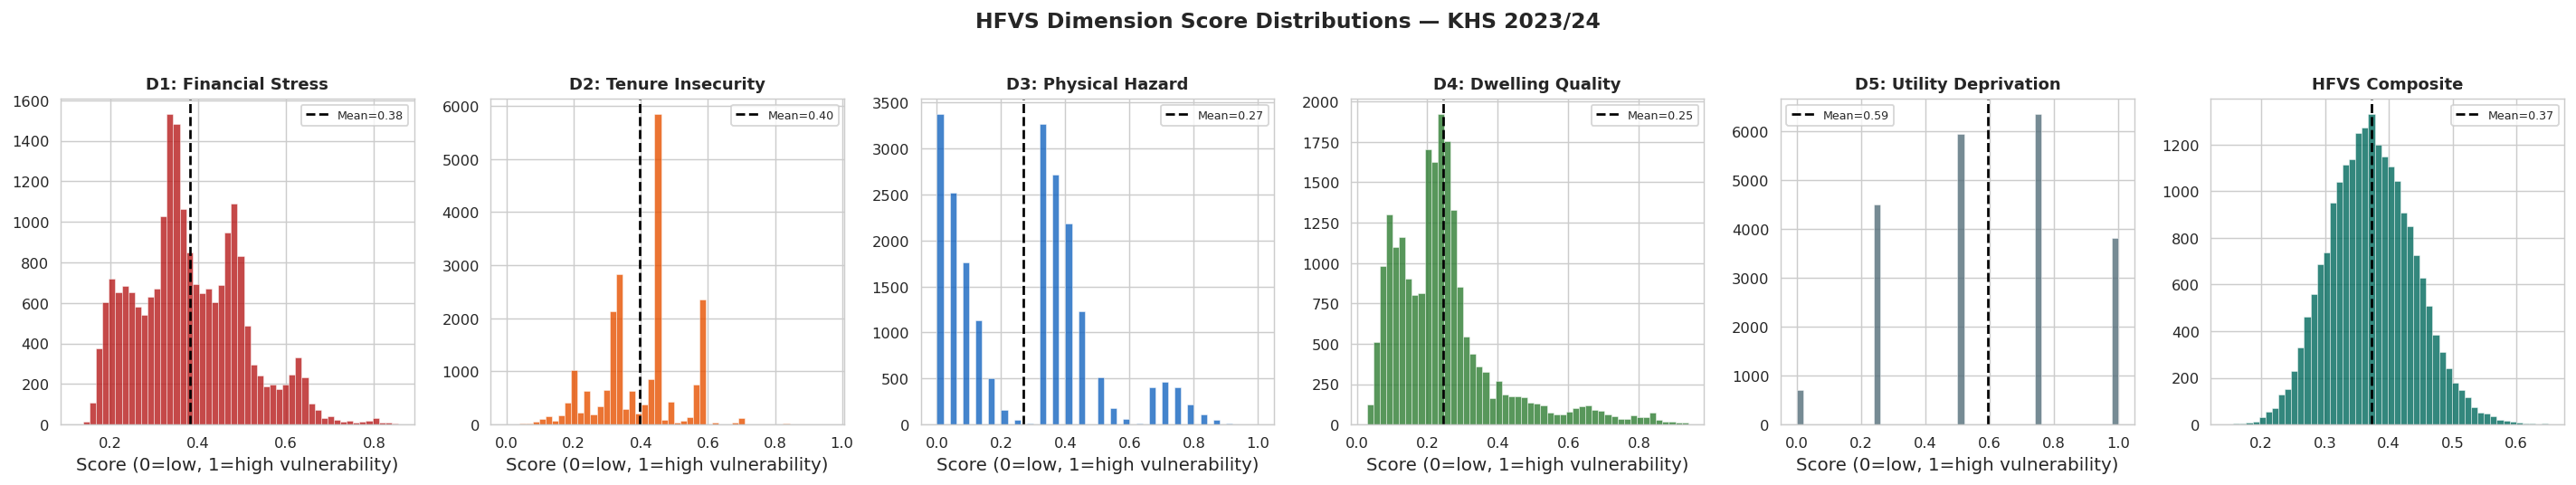

Figure saved.


In [286]:
DIMENSIONS = [
    ('hfvs_d1_financial', 'D1: Financial Stress', RED),
    ('hfvs_d2_tenure',    'D2: Tenure Insecurity', AMBER),
    ('hfvs_d3_hazard',    'D3: Physical Hazard',  BLUE),
    ('hfvs_d4_quality',   'D4: Dwelling Quality', GREEN),
    ('hfvs_d5_utility',   'D5: Utility Deprivation', GRAY),
]

# ── 6.1  HFVS dimension score distributions ──────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for ax, (col, label, color) in zip(axes, DIMENSIONS):
    ax.hist(model_df[col], bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(model_df[col].mean(), color='black', ls='--', lw=1.5, label=f'Mean={model_df[col].mean():.2f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score (0=low, 1=high vulnerability)')
    ax.legend(fontsize=7)

axes[-1].hist(model_df['hfvs_composite'], bins=50, color=TEAL, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[-1].axvline(model_df['hfvs_composite'].mean(), color='black', ls='--', lw=1.5,
                  label=f'Mean={model_df["hfvs_composite"].mean():.2f}')
axes[-1].set_title('HFVS Composite', fontsize=10)
axes[-1].legend(fontsize=7)

plt.suptitle('HFVS Dimension Score Distributions — KHS 2023/24', fontsize=13, fontweight='600', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'hfvs_dimension_distributions.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

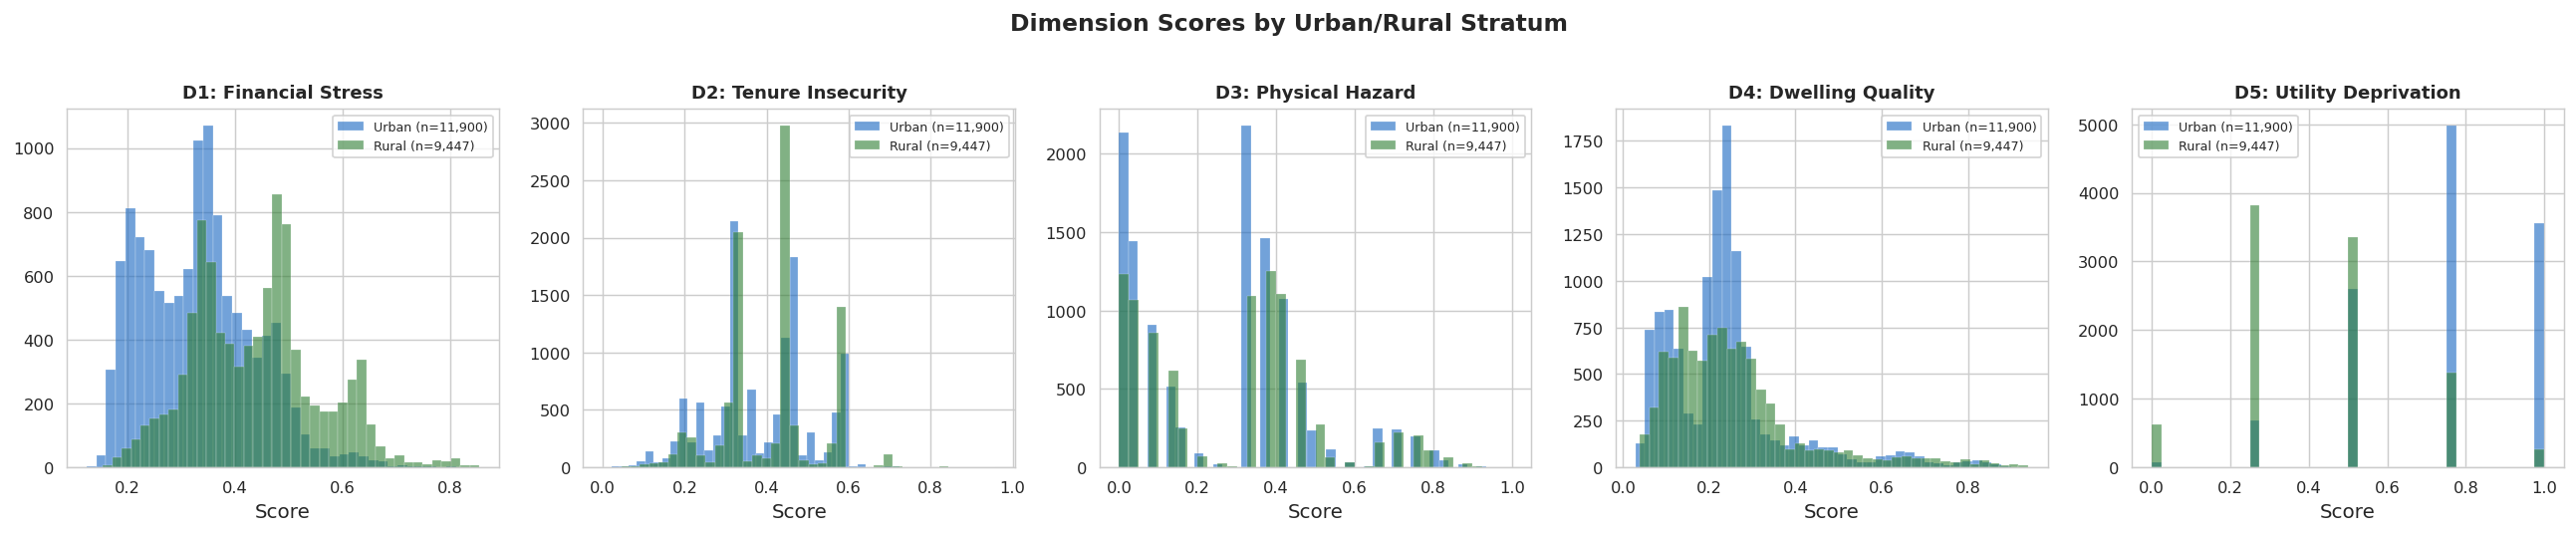

In [287]:
# ── 6.2  Urban vs Rural HFVS comparison ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
urban_labels = {1: 'Urban', 0: 'Rural'}
for ax, (col, label, _) in zip(axes, DIMENSIONS):
    for ur_code, ur_label in urban_labels.items():
        subset = model_df[model_df['is_urban'] == ur_code][col]
        ax.hist(subset, bins=40, alpha=0.6, label=f'{ur_label} (n={len(subset):,})',
                color=BLUE if ur_code == 1 else GREEN, edgecolor='white', linewidth=0.2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score')
    ax.legend(fontsize=7)

plt.suptitle('Dimension Scores by Urban/Rural Stratum', fontsize=13, fontweight='600', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'hfvs_urban_rural.png', bbox_inches='tight')
plt.show()



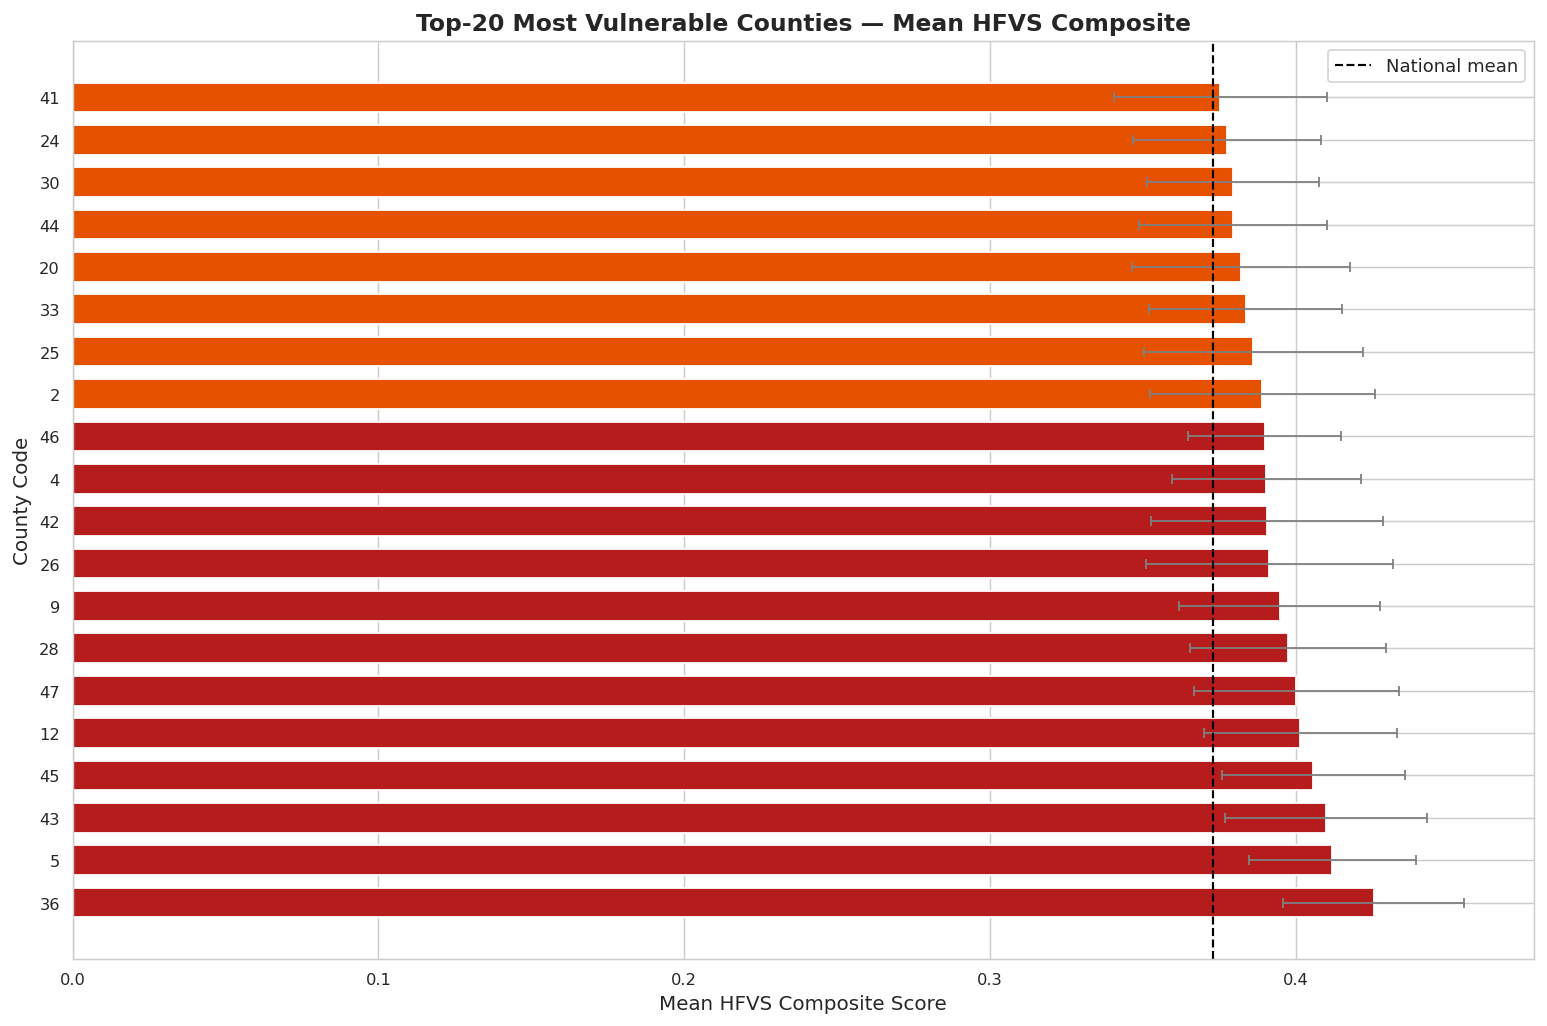

County HFVS table saved.


In [288]:
# ── 6.3  County-level median HFVS heatmap (top 20 counties) ─────────────
county_hfvs = (model_df
               .groupby('county_code')['hfvs_composite']
               .agg(['mean','std','count'])
               .rename(columns={'mean':'HFVS_mean','std':'HFVS_std','count':'n_hh'})
               .sort_values('HFVS_mean', ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
top20 = county_hfvs.head(20)
colors_bar = [RED if v >= county_hfvs['HFVS_mean'].quantile(0.75) else
              AMBER if v >= county_hfvs['HFVS_mean'].median() else
              GREEN for v in top20['HFVS_mean']]

bars = ax.barh(top20.index.astype(str), top20['HFVS_mean'], color=colors_bar, height=0.7)
ax.errorbar(top20['HFVS_mean'], range(len(top20)),
            xerr=top20['HFVS_std']/2, fmt='none', color='gray', capsize=3, lw=1)
ax.axvline(county_hfvs['HFVS_mean'].mean(), color='black', ls='--', lw=1.2, label='National mean')
ax.set_xlabel('Mean HFVS Composite Score')
ax.set_ylabel('County Code')
ax.set_title('Top-20 Most Vulnerable Counties — Mean HFVS Composite')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'county_hfvs_top20.png', bbox_inches='tight')
plt.show()

county_hfvs.to_csv(TABS / 'county_hfvs_summary.csv')
print('County HFVS table saved.')

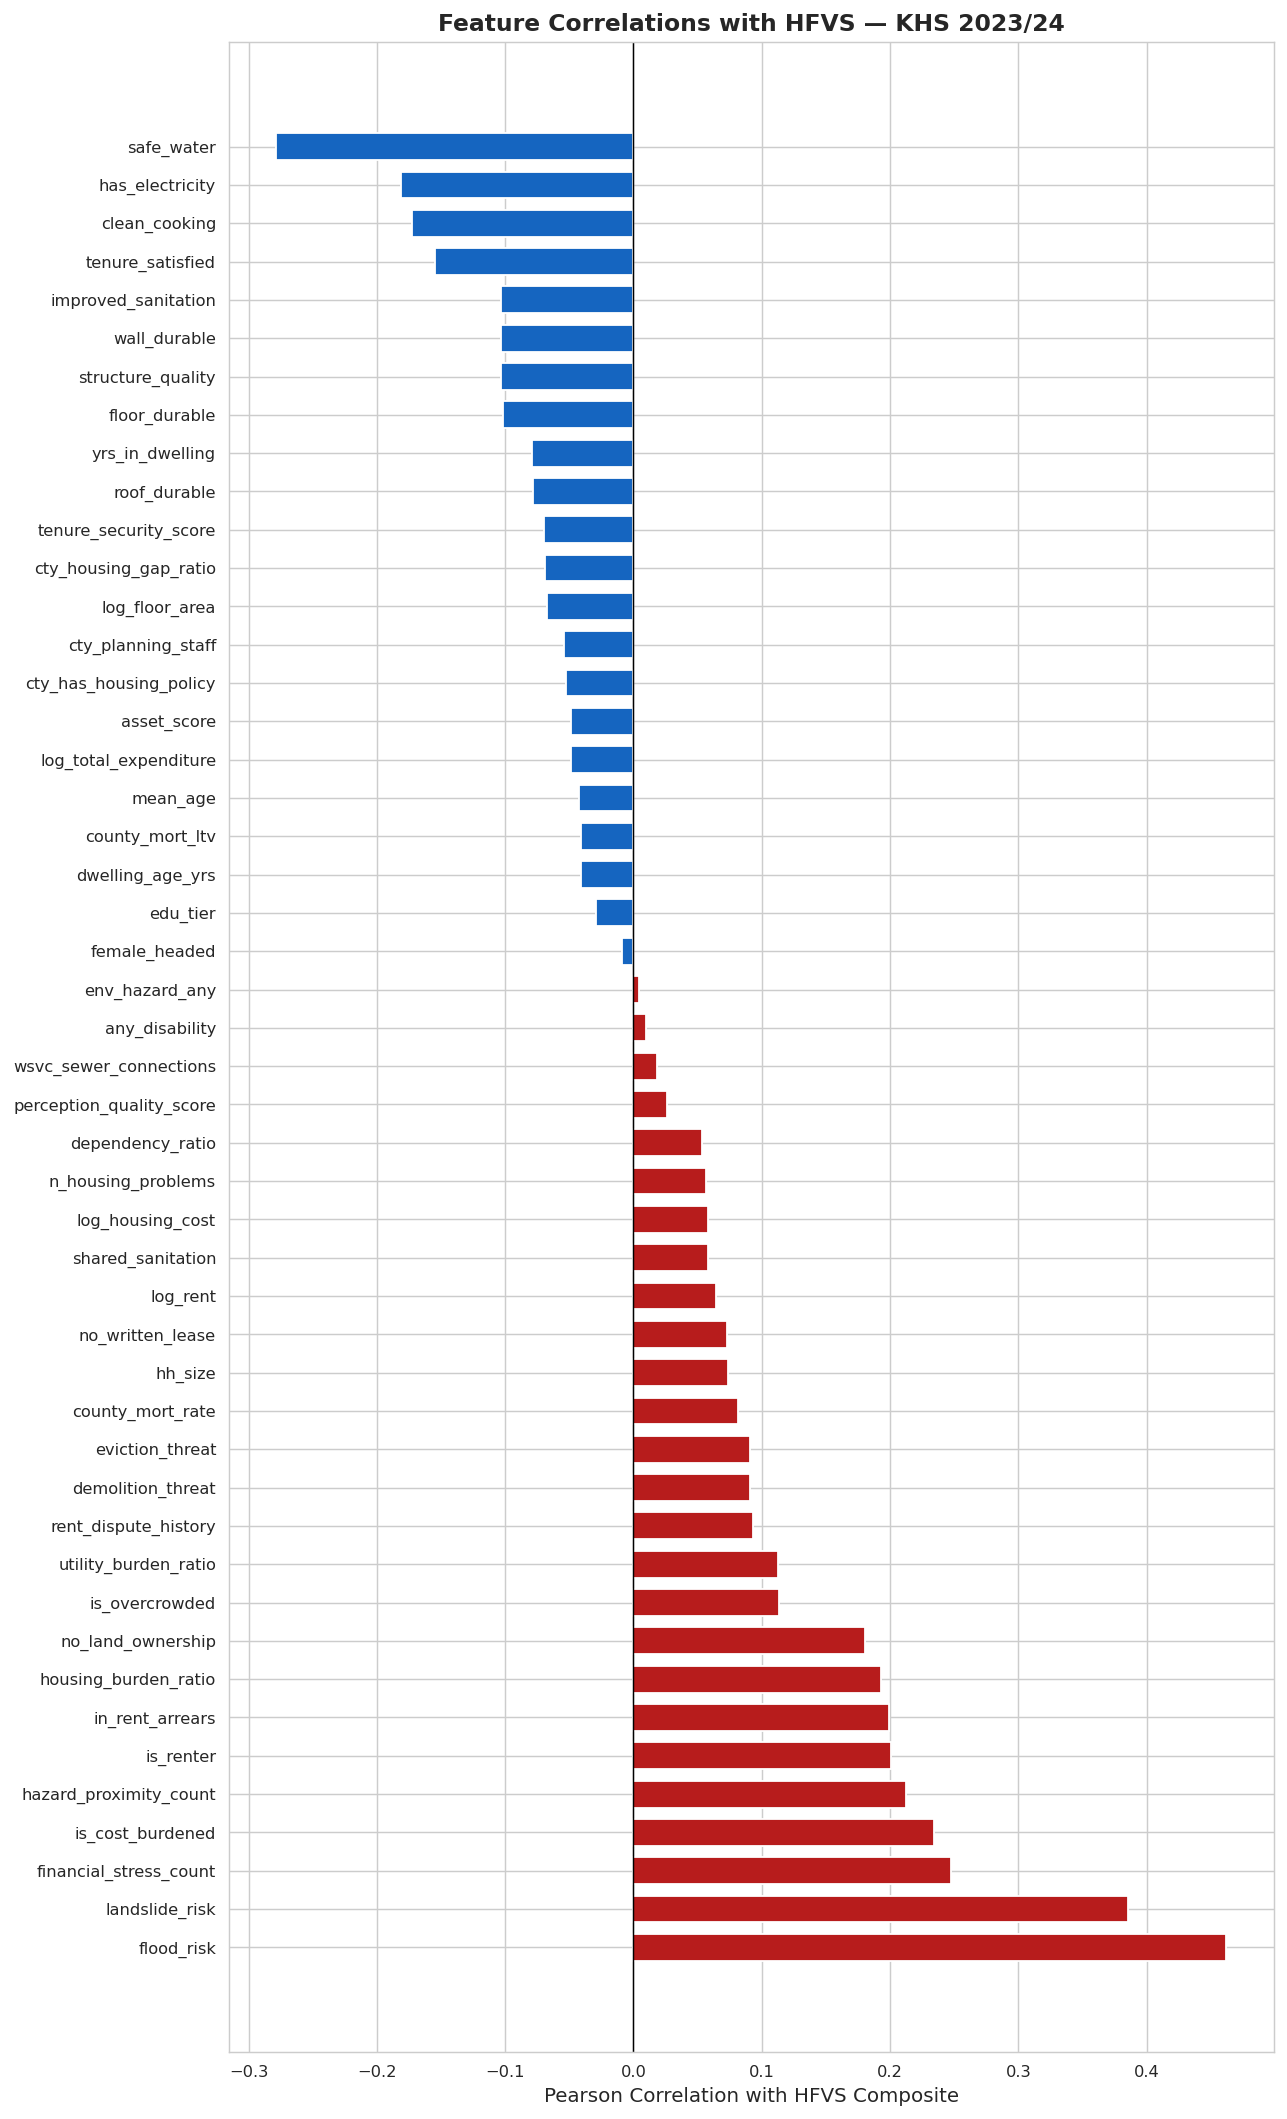

In [289]:
# ── 6.4  Feature correlation with HFVS composite (unchanged logic, now
#     reads from the post-pruning feature list) ──────────────────────────
modelling_features = [
    c for c in model_df.columns
    if FEATURE_MAP.get(c, 'engineered') in ['D1', 'D2', 'D3', 'D4', 'D5', 'control', 'supply']
]
corr_with_hfvs = (
    model_df[modelling_features]
    .corrwith(model_df['hfvs_composite'])
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(10, len(corr_with_hfvs) * 0.3 + 2))
colors_c = [RED if v > 0 else BLUE for v in corr_with_hfvs]
ax.barh(corr_with_hfvs.index, corr_with_hfvs.values, color=colors_c, height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with HFVS Composite')
ax.set_title('Feature Correlations with HFVS — KHS 2023/24')
plt.tight_layout()
plt.savefig(FIGS / 'feature_corr_hfvs.png', bbox_inches='tight')
plt.show()

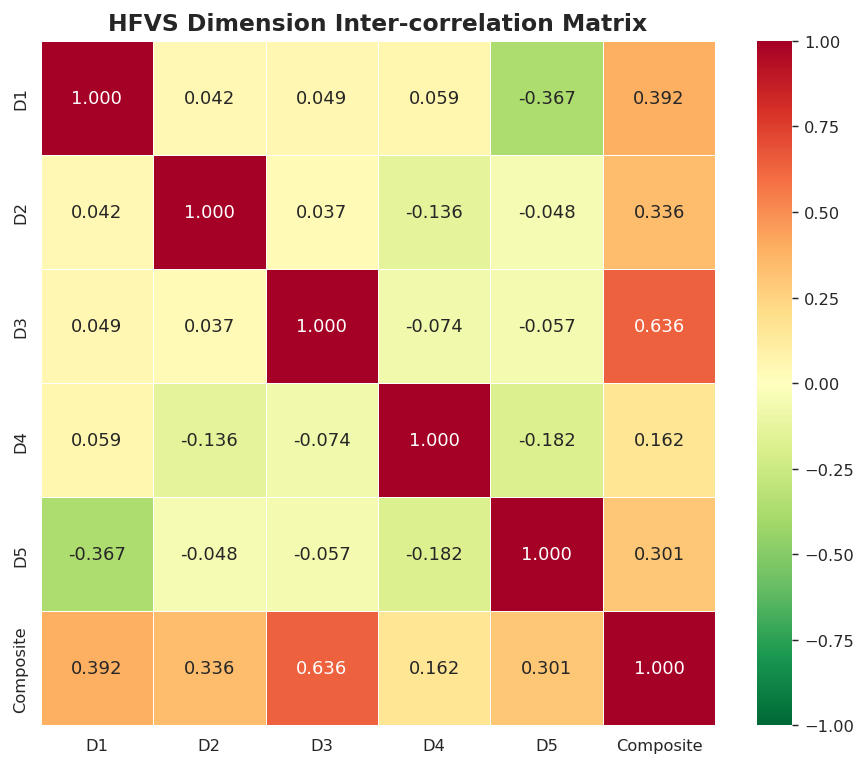

                   hfvs_d1_financial  hfvs_d2_tenure  hfvs_d3_hazard  hfvs_d4_quality  hfvs_d5_utility  hfvs_composite
hfvs_d1_financial             1.0000          0.0423          0.0486           0.0589          -0.3673          0.3924
hfvs_d2_tenure                0.0423          1.0000          0.0367          -0.1358          -0.0483          0.3364
hfvs_d3_hazard                0.0486          0.0367          1.0000          -0.0743          -0.0571          0.6362
hfvs_d4_quality               0.0589         -0.1358         -0.0743           1.0000          -0.1820          0.1624
hfvs_d5_utility              -0.3673         -0.0483         -0.0571          -0.1820           1.0000          0.3008
hfvs_composite                0.3924          0.3364          0.6362           0.1624           0.3008          1.0000


In [290]:

# ── 6.5  Dimension inter-correlation matrix (now 6x6: D1-D5 + composite) ─
dim_cols = [d[0] for d in DIMENSIONS] + ['hfvs_composite']
dim_labels = [d[1].split(':')[0] for d in DIMENSIONS] + ['Composite']
dim_corr = model_df[dim_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dim_corr, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            ax=ax, xticklabels=dim_labels, yticklabels=dim_labels, linewidths=0.5)
ax.set_title('HFVS Dimension Inter-correlation Matrix')
plt.tight_layout()
plt.savefig(FIGS / 'dimension_correlation_matrix.png', bbox_inches='tight')
plt.show()
print(dim_corr.to_string())

In [291]:
# ── 6.6  Descriptive statistics table ────────────────────────────────────
desired_cols = (
    ['hfvs_composite', 'hfvs_p1_financial', 'hfvs_p2_physical', 'hfvs_p3_tenure',
     'high_vulnerability'] +
    [c for c in modelling_features if c in model_df.columns]
)
desc_cols = [c for c in desired_cols if c in model_df.columns]

missing = [c for c in desired_cols if c not in model_df.columns]
if missing:
    print(f'Warning: {len(missing)} columns not in model_df, skipped: {missing}')

desc_stats = model_df[desc_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
desc_stats['missing_pct'] = (model_df[desc_cols].isna().sum() / len(model_df) * 100).values
desc_stats['skewness']    = model_df[desc_cols].apply(lambda x: skew(x.dropna())).values

print(desc_stats.to_string())
desc_stats.to_csv(TABS / 'descriptive_statistics.csv')
print('\nDescriptive statistics saved.')

                              count      mean       std        min      10%      25%      50%       75%       90%       max  missing_pct  skewness
hfvs_composite           21347.0000    0.3732    0.0665     0.1464   0.2886   0.3265   0.3712    0.4176    0.4591    0.6497       0.0000    0.1964
high_vulnerability       21347.0000    0.0328    0.1782     0.0000   0.0000   0.0000   0.0000    0.0000    0.0000    1.0000       0.0000    5.2427
log_total_expenditure    21347.0000    9.7384    0.9641     2.1972   8.6017   9.0939   9.6928   10.3673   11.0541   12.2405       0.0000   -0.2647
log_housing_cost         21347.0000    6.4367    3.1162     0.0000   0.0000   5.9940   7.3139    8.4972    9.4728   11.4076       0.0000   -1.1316
housing_burden_ratio     21347.0000    0.1428    0.1473     0.0000   0.0000   0.0280   0.1149    0.1975    0.3247    1.0000       0.0000    1.8940
is_cost_burdened         21347.0000    0.1173    0.3217     0.0000   0.0000   0.0000   0.0000    0.0000    1.0000    1

---
## §7 — Export

Three outputs:
1. `model_ready.parquet` — full feature-engineered dataset for modelling notebook
2. `model_ready.csv` — human-readable version for inspection
3. `feature_map.csv` — feature metadata table for documentation


In [292]:
# ── 7.1  Export parquet (primary) ────────────────────────────────────────
out_parquet = PQ / 'model_ready.parquet'
model_df.to_parquet(out_parquet, index=False)
print(f'Saved: {out_parquet}  ({model_df.shape[0]:,} rows × {model_df.shape[1]} cols)')

# ── 7.2  Export CSV (inspection copy) ────────────────────────────────────
out_csv = TABS / 'model_ready.csv'
model_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

# ── 7.3  Feature map metadata ─────────────────────────────────────────────
feature_meta = pd.DataFrame([
    {'feature': col,
     'pillar': FEATURE_MAP.get(col, 'engineered'),
     'dtype': str(model_df[col].dtype),
     'missing_pct': model_df[col].isna().mean()*100,
     'mean': model_df[col].mean() if model_df[col].dtype != object else None,
     'std':  model_df[col].std()  if model_df[col].dtype != object else None,
    }
    for col in model_df.columns
])

out_meta = TABS / 'feature_map.csv'
feature_meta.to_csv(out_meta, index=False)
print(f'Saved: {out_meta}')
print(feature_meta.to_string())

Saved: /content/drive/MyDrive/KHS_Dissertation/data/parquet/model_ready.parquet  (21,347 rows × 59 cols)
Saved: /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301/model_ready.csv
Saved: /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301/feature_map.csv
                     feature      pillar    dtype  missing_pct      mean       std
0             interview__key          id   object       0.0000       NaN       NaN
1                county_code          id    Int64       0.0000   24.6134   13.9186
2                   is_urban     stratum     int8       0.0000    0.5575    0.4967
3                   hhweight      weight  float64       0.0000  650.4955  615.4876
4      log_total_expenditure          D1  float64       0.0000    9.7384    0.9641
5           log_housing_cost          D1  float64       0.0000    6.4367    3.1162
6       housing_burden_ratio          D1  float64       0.0000    0.1428    0.1473
7           is_cost_burdened          D1  float64       0.0

In [293]:
print([c for c in model_df.columns if 'key' in c or 'id' in c or 'interview' in c])

['interview__key', 'landslide_risk']


In [294]:

print('=== FINAL DATASET HEALTH CHECK ===')
print(f'Shape                : {model_df.shape}')
print(f'Total missing cells  : {model_df.isnull().sum().sum()}')
print(f'Duplicate keys       : {model_df["interview__key"].duplicated().sum()}')
print(f'\nTarget distribution  :')
print(model_df['high_vulnerability'].value_counts(normalize=True).mul(100).round(2).to_string())

print(f'\nDimension score summary :')
for col, label, _ in DIMENSIONS:
    s = model_df[col]
    print(f'  {col:<22} ({label:<26}): mean={s.mean():.3f}  std={s.std():.3f}  '
          f'range=[{s.min():.3f}, {s.max():.3f}]')
s = model_df['hfvs_composite']
print(f'  {"hfvs_composite":<22} ({"Composite":<26}): mean={s.mean():.3f}  std={s.std():.3f}  '
      f'range=[{s.min():.3f}, {s.max():.3f}]')

print(f'\n✓ Data understanding, cleaning, and engineering complete — 5-dimension HFVS, '
      f'household key preserved, dimensionality verified rather than assumed.')


=== FINAL DATASET HEALTH CHECK ===
Shape                : (21347, 59)
Total missing cells  : 0
Duplicate keys       : 0

Target distribution  :
high_vulnerability
0   96.7200
1    3.2800

Dimension score summary :
  hfvs_d1_financial      (D1: Financial Stress      ): mean=0.380  std=0.123  range=[0.124, 0.855]
  hfvs_d2_tenure         (D2: Tenure Insecurity     ): mean=0.396  std=0.122  range=[0.000, 0.958]
  hfvs_d3_hazard         (D3: Physical Hazard       ): mean=0.269  std=0.218  range=[0.000, 1.000]
  hfvs_d4_quality        (D4: Dwelling Quality      ): mean=0.246  std=0.151  range=[0.029, 0.940]
  hfvs_d5_utility        (D5: Utility Deprivation   ): mean=0.595  std=0.276  range=[0.000, 1.000]
  hfvs_composite         (Composite                 ): mean=0.373  std=0.067  range=[0.146, 0.650]

✓ Data understanding, cleaning, and engineering complete — 5-dimension HFVS, household key preserved, dimensionality verified rather than assumed.
